In [1]:
import datetime, calendar, glob, os

import pickle as pkl
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.colors as mcolors
import matplotlib.dates as mdates

from skfda.exploratory.depth import ModifiedBandDepth, IntegratedDepth
from skfda import FDataGrid

from matplotlib import cm
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.transforms import ScaledTranslation
from matplotlib.ticker import FuncFormatter

from fdu import functional_dynamic_update
from utils import _get_hyper, _get_band_fraction, _KS
from fda_utils import _fDepth, _fQuantile

plt.rcParams["legend.handlelength"] = 1
plt.rcParams["legend.handleheight"] = 1.125
plt.rcParams["font.family"] = "Avenir"

path_to_fDepth = "/Users/Guille/Desktop/dynamic_update/functional_forecast_dynamic_update/fDepth"
path_to_data = "/Users/Guille/Desktop/dynamic_update/data"
path_to_images = "/Users/Guille/Desktop/dynamic_update/images"
path_to_params = "/Users/Guille/Desktop/dynamic_update/params"
path_to_validation = "/Users/Guille/Desktop/dynamic_update/validation"

# Loading color palette
palette_ = pd.read_csv(path_to_data + "/palette.csv")
print(palette_)

# Loading Texas map
_TX = gpd.read_file(path_to_data + "/maps/TX/State.shp")

T = 288
resource = 'wind'

      miro      ibm
0  #013396  #648FFF
1  #B1C06E  #785EF0
2  #056534  #DC267F
3  #F80202  #FE6100
4  #FDD906  #FFB000
5  #FCF795      NaN
6  #CCEDFF      NaN
7  #FDD60B      NaN
8  #FCE9D0      NaN


# Historical random curves and day-ahead forecasts

In [2]:
# Load 2017 data as training set
with open(path_to_data + f"/preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
print(F_tr_.shape, E_tr_.shape)
    
# Load 2018 data as testing set
with open(path_to_data + f"/preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
#print(assets_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
#print(F_ts_.shape, E_ts_.shape)

# Short testing set with training set order
order  = {v: i for i, v in enumerate(assets_tr_)}
idx_   = np.argsort([order[x] for x in assets_ts_])
F_ts_  = F_ts_[:, :, idx_]
E_ts_  = E_ts_[:, :, idx_]
print(F_ts_.shape, E_ts_.shape)

# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
#print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))

# No possble a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_ts_[F_ts_ > 1.] = 1.
E_tr_[E_tr_ > 1.] = 1.
E_ts_[E_ts_ > 1.] = 1.
print(F_tr_.max(), E_tr_.max())
print(F_ts_.max(), F_ts_.max())

F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ < 0.] = 0.
print(F_tr_.min(), E_tr_.min())
print(F_ts_.min(), E_ts_.min())

F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()

# Format training set from day x interval x asset to [day * asset] x interval
E_ts_bias_ = E_ts_.copy()
E_tr_bias_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
print(E_tr_bias_.shape, E_ts_bias_.shape)

(363, 288, 187) (363, 288, 187)
(364, 288, 187) (364, 288, 187)
1.0 0.9999999888984703
1.0 1.0
0.0 0.0
0.0 0.0
(67881, 288) (364, 288, 187)


In [3]:
# Load 2017 data as training set
with open(path_to_data + f"/linear_preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
print(F_tr_.shape, E_tr_.shape)

# Unbias training set
B_tr_ = np.mean(F_tr_ - E_tr_, axis = 0)
for i in range(E_tr_.shape[-1]):
    E_tr_[:, :, i] += B_tr_[:, i]
    
# Load 2018 data as testing set
with open(path_to_data + f"/linear_preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
#print(assets_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
#print(F_ts_.shape, E_ts_.shape)

# Short testing set with training set order
order  = {v: i for i, v in enumerate(assets_tr_)}
idx_   = np.argsort([order[x] for x in assets_ts_])
F_ts_  = F_ts_[:, :, idx_]
E_ts_  = E_ts_[:, :, idx_]
print(F_ts_.shape, E_ts_.shape)

# Unbias testing set
B_ts_ = np.mean(F_ts_ - E_ts_, axis = 0)
for i in range(E_ts_.shape[-1]):
    E_ts_[:, :, i] += B_ts_[:, i]

# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
#print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))

# No possble a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_ts_[F_ts_ > 1.] = 1.
E_tr_[E_tr_ > 1.] = 1.
E_ts_[E_ts_ > 1.] = 1.
print(F_tr_.max(), E_tr_.max())
print(F_ts_.max(), F_ts_.max())

F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ < 0.] = 0.
print(F_tr_.min(), E_tr_.min())
print(F_ts_.min(), E_ts_.min())

F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()

# Format training set from day x interval x asset to [day * asset] x interval
E_ts_lin_ = E_ts_.copy()
E_tr_lin_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
print(E_ts_lin_.shape, E_tr_lin_.shape)

(363, 288, 187) (363, 288, 187)
(364, 288, 187) (364, 288, 187)
1.0 1.0
1.0 1.0
0.0 0.0
0.0 0.0
(364, 288, 187) (67881, 288)


In [4]:
# Load 2017 data as training set
with open(path_to_data + f"/preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
x_tr_      = _data["locations"]
dates_tr_  = _data["dates"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, x_tr_.shape, dates_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
T_tr_ = dates_tr_.reshape(int(dates_tr_.shape[0]/T), T)
print(F_tr_.shape, E_tr_.shape, T_tr_.shape)

# Unbias training set
B_tr_ = np.mean(F_tr_ - E_tr_, axis = 0)
for i in range(E_tr_.shape[-1]):
    E_tr_[:, :, i] += B_tr_[:, i]
    
# Load 2018 data as testing set
with open(path_to_data + f"/preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
x_ts_      = _data["locations"]
dates_ts_  = _data["dates"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
#print(assets_ts_.shape, x_ts_.shape, dates_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
T_ts_ = dates_ts_.reshape(int(dates_ts_.shape[0]/T), T)
#print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

dt_ = np.array([t * 5 for t in range(T)])
dx_ = pd.to_datetime(pd.DataFrame({"time": dt_}).time, unit = "m").dt.strftime("%H:%M").to_numpy()
#print(dt_.shape, dx_.shape)

# Short testing set with training set order
order      = {v: i for i, v in enumerate(assets_tr_)}
idx_       = np.argsort([order[x] for x in assets_ts_])
assets_ts_ = assets_ts_[idx_]
x_ts_      = x_ts_[idx_]
F_ts_      = F_ts_[:, :, idx_]
E_ts_      = E_ts_[:, :, idx_]
print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

# Unbias testing set
B_ts_ = np.mean(F_ts_ - E_ts_, axis = 0)
for i in range(E_ts_.shape[-1]):
    E_ts_[:, :, i] += B_ts_[:, i]
    
# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
#print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))
# print(F_tr_.min(), F_tr_.max())
# print(E_tr_.min(), E_tr_.max())
# print(F_ts_.min(), F_ts_.max())
# print(E_ts_.min(), E_ts_.max())

# No possible a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_ts_[F_ts_ > 1.] = 1.
E_tr_[E_tr_ > 1.] = 1.
E_ts_[E_ts_ > 1.] = 1.
print(F_tr_.max(), E_tr_.max())
print(F_ts_.max(), F_ts_.max())

F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ < 0.] = 0.
print(F_tr_.min(), E_tr_.min())
print(F_ts_.min(), E_ts_.min())

F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()

# Format training set from day x interval x asset to [day * asset] x interval
T_tr_ = np.concatenate([T_tr_ for k in range(assets_tr_.shape[0])], axis = 0)
assets_tr_ = np.concatenate([np.tile(assets_tr_[k], (F_tr_.shape[0], 1)) for k in range(assets_tr_.shape[0])], axis = 0)
X_tr_ = np.concatenate([np.tile(x_tr_[k, :], (F_tr_.shape[0], 1)) for k in range(x_tr_.shape[0])], axis = 0)
F_tr_ = np.concatenate([F_tr_[..., k] for k in range(F_tr_.shape[2])], axis = 0)
E_tr_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
print(X_tr_.shape, assets_tr_.shape, F_tr_.shape, E_tr_.shape, T_tr_.shape)
print(x_ts_.shape, assets_ts_.shape, F_ts_.shape, E_ts_.shape, T_ts_.shape)

t_tr_ = np.array([datetime.datetime.strptime(t_tr, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday 
                  for t_tr in T_tr_[:, 0]]) - 1

t_ts_ = np.array([datetime.datetime.strptime(t_ts, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday
                  for t_ts in T_ts_[:, 0]]) - 1
#print(t_tr_.shape, t_ts_.shape)

(363, 288, 187) (363, 288, 187) (363, 288)
(364, 288, 187) (364, 288, 187) (364, 288)
1.0 1.0
1.0 1.0
0.0 0.0
0.0 0.0
(67881, 2) (67881, 1) (67881, 288) (67881, 288) (67881, 288)
(187, 2) (187,) (364, 288, 187) (364, 288, 187) (364, 288)


In [5]:
hyper_ = pd.read_csv(path_to_params + f'/wind-fusion-hyper.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)
print(hyper_)

envelop_ = pd.read_csv(path_to_params + f'/wind-fusion-envelop-FIS.csv')
envelop_ = envelop_.set_index("time")
#print(envelop_)

depth_ = pd.read_csv(path_to_params + f'/wind-fusion-depth-FIS.csv')
depth_ = depth_.set_index("time")
#print(depth_)

                     72        144       216
parameter                                   
forget_rate_f     0.0625    0.0625    0.0625
forget_rate_e     2.0000    1.0000    0.5000
lookup_rate       2.0000    2.0000    1.0000
length_scale_f    0.0050    0.0050    0.0050
length_scale_e    0.0500    0.0750    0.1000
trust_rate        0.5000    0.3000    0.1000
nu                8.0000    8.0000    8.0000
xi                0.4000    0.5000    0.6000
gamma            60.0000   50.0000   40.0000
kappa           175.0000  150.0000  125.0000
p_fusion          0.6000    0.7000    0.7500


# Functional kNNs dynamic update

In [6]:
import importlib
import fdu

asset = 21                                                                                                                                                                                                                                                          
day = 80
interval = 72

#_distances = {'temporal': 'None', 'spatial': 'None'}
_distances = {'temporal': 'seasonal', 'spatial': 'euclidean'}
#_distances = {'temporal': 'seasonal_equinox', 'spatial': 'haversine'}

_fdu = functional_dynamic_update(_distances, assets_ts_[asset], T_ts_[day, interval])
print(_fdu.name, _fdu.date)

# Filter solar hours with loading solar set
idx_days_ = np.absolute(t_tr_ - day) < 7
idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) + np.sum(E_tr_bias_[idx_days_, :], axis = 0)) > 1.

_fdu.fit(F_tr_, E_tr_lin_, dt_, 
         X_ = X_tr_, 
         x_ = x_ts_[asset, :], 
         t_ = t_tr_, 
         t = t_ts_[day], 
         interval_mask = idx_hours_)

M_ = _fdu.predict(F_ts_[day, :interval, asset], E_ts_lin_[day, :, asset],
                  forget_rate_f = _get_hyper(hyper_, 'forget_rate_f', interval),
                  forget_rate_e = _get_hyper(hyper_, 'forget_rate_e', interval),
                  length_scale_f = _get_hyper(hyper_, 'length_scale_f', interval),
                  length_scale_e = _get_hyper(hyper_, 'length_scale_e', interval),
                  lookup_rate = _get_hyper(hyper_, 'lookup_rate', interval),
                  trust_rate = _get_hyper(hyper_, 'trust_rate', interval),
                  nu = _get_hyper(hyper_, 'nu', interval),
                  gamma = _get_hyper(hyper_, 'gamma', interval),
                  xi = _get_hyper(hyper_, 'xi', interval),
                  kappa = _get_hyper(hyper_, 'kappa', interval),
                  p_fusion = _get_hyper(hyper_, 'p_fusion', interval))

e_ = E_ts_[day, :, asset]
e_lin_ = E_ts_lin_[day, :, asset]
e_bias_ = E_ts_bias_[day, :, asset]
f_ = F_ts_[day, :interval, asset]
f_hat_ = F_ts_[day, interval:, asset]

file_name = f"{resource}-{asset}-{day}-{interval}"
print(file_name)

Bobcat Bluff repower 2018-03-22 06:00:00
72 216
(72,) (216,)
(72,)
(72,) (216,) (288,)
wind-21-80-72


In [ ]:
print(dt_, dx_)

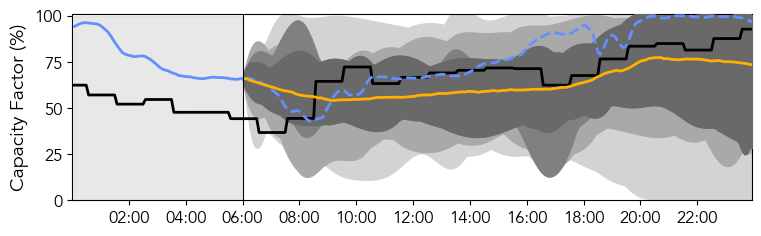

In [13]:
def _plot_envelop(_ax, _upper, _lower, m_, f_, f_hat_, e_, dt_, dx_, interval, 
                  color = palette_.loc[4, "ibm"],
                  label = r"$\bar{\mu} (s)$",
                  CR = 'CR',
                  legend_1 = True, 
                  legend_2 = True):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]
    dt   = dt_[1] - dt_[0]

    _ax.plot(dt_ + dt, 100*e_, 
             c = "k", 
             lw = 2, 
             clip_on = True,
             label = "CF (forecast)" if legend_1 else None, 
             zorder = 8)

    _ax.plot(tau_ + dt, 100*f_, 
             c = palette_.loc[0, "ibm"], 
             clip_on = True,
             label = "CF (actual)" if legend_1 else None, 
             lw = 2, 
             zorder = 9)
    
    _ax.plot(s_ + dt, 100*f_hat_, 
             clip_on = True,
             c = palette_.loc[0, "ibm"], 
             ls = "--", 
             lw = 2, 
             zorder = 9)

    _ax.plot(s_ + dt, 100*m_[1:], 
             c = color, 
             label = label if legend_2 else None,
             lw = 2, 
             zorder = 10)
    
    colors_ = ["lightgray", "darkgray", "gray", "dimgray"]
    for color, key, i in zip(colors_, _upper.keys(), range(len(_upper.keys()))):
        u_ = _upper[key]
        l_ = _lower[key]

        cr = int((1. - float(key))*100)

        _ax.fill_between(dt_[-u_.shape[0]:] + dt, 100*u_, 100*l_,
                         color  = color,
                         label  = f"{cr}% {CR}" if legend_2 else None,
                         zorder = i + 1)

    _ax.fill_between(tau_ + dt, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color = "lightgray",
                     alpha = 0.5)

    _ax.axvline(dt_[interval - 1] + dt, 
                color = "k", 
                linewidth = 0.75, 
                #label = "Event (update)",
                zorder = 11)
    
    _ax.set_xticks(dt_[24::24], dx_[24::24], rotation=0)
        
    _ax.tick_params(axis = "both", 
                    labelsize = 12)
    
    _ax.set_ylim(0, 101)
    _ax.set_xlim(dt_[0], dt_[-1])
    _ax.set_ylabel("Capacity Factor (%)", size = 14)

# Samples in each confidence band
dist = 'fknn'
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = IntegratedDepth()
_depth = ModifiedBandDepth()

M_int_, M_int_ds_ = _fdu.functional_downsampling(subsample = 12,
                                                 n_basis = 20) 



J_ = _fdu.focal_curve_envelope(_depth, M_int_, dist, max_iter = 100)

k_ = _get_band_fraction(envelop_, alpha_, dist, interval)

f_focal_ext_, _upper, _lower = _fdu.focal_envelop_confidence_bands(alpha_, k_)

_fig, _ax = plt.subplots(figsize = (7.5, 2.25), constrained_layout = True)

_plot_envelop(_ax, _upper, _lower, f_focal_ext_, f_, f_hat_, e_bias_, dt_, dx_, interval, 
              color = palette_.loc[4, "ibm"],
              label = r"$\bar{f} (s)$",
              CR = 'CR',
              legend_1 = False, 
              legend_2 = False)

# _ax.legend(frameon = False, 
#            loc = (0.1875, .825),
#            fontsize = 12,
#            columnspacing=0.5,
#            handletextpad=0.25,
#            ncol = 5)

# plt.savefig(path_to_images + f"/focal_curve_envelop-{file_name}.pdf", 
#             bbox_inches = "tight")

plt.show()

# Visualization Utils

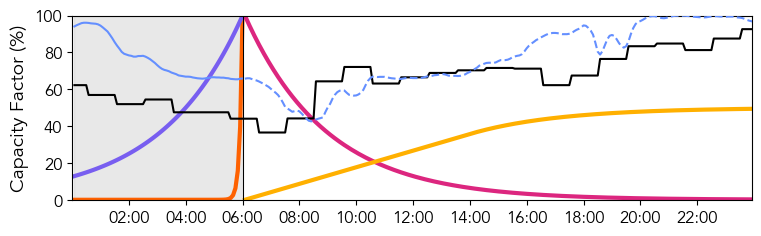

In [14]:
def _plot_forecast_parameters(_ax, phi_, psi_, eta_, f_, f_hat_, e_, dx_, dt_, interval,
                              labels_1 = False,
                              labels_2 = False):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]
    dt   = dt_[1] - dt_[0]

    _ax.plot(tau_ + dt, 100. * f_, 
             c=palette_.loc[0, "ibm"], 
             label="CF (actual)" if labels_1 else None, 
             lw=1.5, 
             zorder=5)

    _ax.plot(s_ + dt, 100. * f_hat_, 
             c=palette_.loc[0, "ibm"], 
             lw=1.5, 
             ls="--", 
             zorder=5)

    _ax.plot(dt_ + dt, 100. * e_, 
             lw=1.5, 
             label="CF (forecast)" if labels_1 else None, 
             c="k", 
             zorder=4)

    _ax.axvline(dt_[interval - 1] + dt, 
                color="k", 
                lw=0.75, 
                label="Event (update)" if labels_1 else None, 
                zorder=6)

    _ax.plot(tau_ + dt, 100. * phi_,
             c=palette_.loc[3, "ibm"],
             lw=3,
             label=r"$\phi_{\varepsilon_f} (\tau)$" if labels_2 else None,
             zorder=2)
    
    _ax.plot(tau_ + dt, 100. * psi_[:interval],
             c=palette_.loc[1, "ibm"],
             lw=3,
             label=r"$\phi_{\varepsilon_e} (\tau)$" if labels_2 else None,
             zorder=2)

    _ax.plot(s_ + dt, 100. * psi_[interval:],
             c=palette_.loc[2, "ibm"],
             lw=3,
             label=r"$\psi_{\eta} (s)$" if labels_2 else None,
             zorder=2)

    _ax.plot(s_ + dt, 100. * eta_,
             c=palette_.loc[4, "ibm"],
             lw=3,
             label=r"$\sigma_{\alpha} (s)$" if labels_2 else None,
             zorder=2)

    _ax.fill_between(tau_ + dt, 100. * np.ones(tau_.shape), 100. * np.zeros(tau_.shape),
                     color="lightgray",
                     alpha=0.5,
                     zorder=1)

    _ax.set_xticks(dt_[24::24], dx_[24::24], rotation=0)
    _ax.set_ylabel("Capacity Factor (%)", size=14)
    _ax.tick_params(axis="both", labelsize=12)
    _ax.set_ylim(0.0, 100)
    _ax.set_xlim(dt_[0], dt_[-1])

fig, _ax = plt.subplots(figsize = (7.5, 2.25), constrained_layout = True)

_plot_forecast_parameters(_ax, _fdu.phi_, _fdu.psi_, _fdu.eta_, f_, f_hat_, e_bias_, dx_, dt_, interval,
                          labels_1 = True,
                          labels_2 = False)

# _ax.legend(frameon=False, 
#            ncol=2, 
#            loc=(0.0125,0.7), 
#            #loc=(0.362,0.625), 
#            fontsize=12)
        
plt.savefig(path_to_images + f"/hyper-{file_name}.pdf", 
            bbox_inches = "tight")

plt.show()

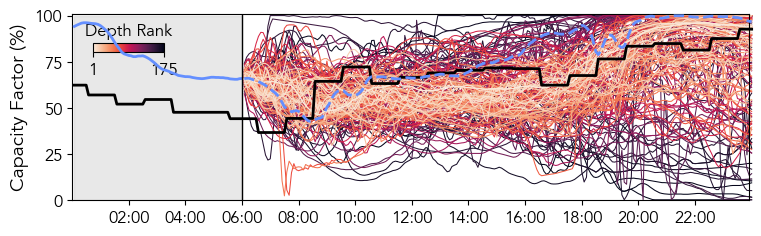

In [15]:
def _plot_depth(_fig, _ax, palette_, M_, f_, f_hat_, e_, w_, dx_, dt_, interval,
                colorbar = True):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]
    dt   = dt_[1] - dt_[0]

    idx_  = np.argsort(w_)
    _cmap = sns.color_palette("rocket", as_cmap=True)
    _norm = plt.Normalize(0., 1)

    _ax.plot([], [], 
             lw = 0.75,
             label = r"$\hat{\mu}_i(s)$", 
             c = "k")

    for i in range(idx_.shape[0]):
        _ax.plot(s_ + dt, 100. * M_[idx_[i], :],
                 c = _cmap(_norm(i/idx_.shape[0])), 
                 lw = 0.75, 
                 zorder = 0, 
                 clip_on = False)

    _ax.plot(dt_[:f_.shape[0]] + dt, 100. * f_,
             c = palette_.loc[0, "ibm"],
             #label = "CF (ac)",
             zorder = 9,
             lw = 2, 
             clip_on = False)

    _ax.plot(dt_[-f_hat_.shape[0]:] + dt, 100. * f_hat_,
             c = palette_.loc[0, "ibm"],
             zorder = 9,
             lw = 2,
             ls = "--", 
             clip_on = False)

    _ax.plot(dt_ + dt, 100. * e_, 
             lw = 2, 
             #label = "CF (fc)", 
             zorder = 8,
             c = "k", 
             clip_on = False)

    _ax.axvline(dt_[f_.shape[0] - 1] + dt, 
                color = "k", 
                lw = 1, 
                #label  = "Event (update)", 
                zorder = 10)
        
    _ax.fill_between(tau_ + dt, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color = "lightgray",
                     alpha = 0.5,
                     zorder = 1)
    
    _ax.set_xticks(dt_[24::24], dx_[24::24], rotation=0)
    # ax_[2].set_yticks(size = 12)
    _ax.set_ylim(0., 101)
    _ax.set_xlim(dt_[0], dt_[-1])
    _ax.set_ylabel("Capacity Factor (%)", size=14)
    
    _ax.tick_params(axis = "both", 
                    labelsize = 12)
    
    if colorbar:
        cbar = _fig.colorbar(cm.ScalarMappable(_norm, sns.color_palette("rocket_r", as_cmap = True)),
                             cax         = _ax.inset_axes([45, 80, 150, 5], transform = _ax.transData),
                             orientation = "horizontal")
    
        cbar.set_ticks([0, 1], 
                       labels = [1, M_.shape[0]], 
                       size = 12)
            
        cbar.ax.set_title("Depth Rank", 
                          rotation = 0, 
                          size = 12)


_fig, _ax = plt.subplots(figsize = (7.5, 2.25), constrained_layout = True)

depth = 'MBD'
depth_rank_ = _fDepth(_fdu.M_int_ds_, depth, path_to_fDepth).to_numpy()[:, 0]

_plot_depth(_fig, _ax, palette_, M_, f_, f_hat_, e_bias_, depth_rank_, dx_, dt_, interval,
            colorbar = True)

# _ax.legend(frameon = False, 
#            loc = (0.4, .825),
#            fontsize = 12,
#            columnspacing=0.5,
#            handletextpad=0.2,
#            ncol = 5)

plt.savefig(path_to_images + f"/ranking-{depth}_{file_name}.pdf", 
            bbox_inches = "tight")

plt.show()

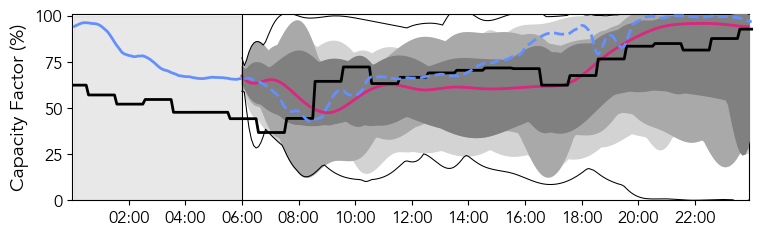

In [16]:
def _plot_enhanced_functional_boxplot(_ax, _upper, _lower, m_, f_, f_hat_, e_, dt_, dx_, interval,
                                      legend_1 = True, 
                                      legend_2 = True):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]
    dt   = dt_[1] - dt_[0]

    _ax.plot(dt_ + dt, 100 * e_, 
             c = "k", 
             lw = 2, 
             zorder = 8,
             #label = "CF (forecast)" if legend_1 else None
             clip_on = False)

    _ax.plot(tau_ + dt, 100 * f_, 
             c = palette_.loc[0, "ibm"], 
             #label = "CF (actual)" if legend_1 else None, 
             zorder = 9,
             lw = 2, 
             clip_on = False)

    _ax.plot(s_ + dt, 100 * f_hat_, 
             c  = palette_.loc[0, "ibm"], 
             lw = 2, 
             ls = "--", 
             zorder = 9,
             clip_on = False)
    #m_p_ = np.concatenate([f_[-1] * np.ones((1,)), m_], axis=0)

    _ax.plot(dt_[-m_.shape[0]:] + dt, 100 * m_, 
             c = palette_.loc[2, "ibm"], 
             ls = '-',
             zorder = 4,
             label = r"$\bar{\mu} (s)$" if legend_1 else None,
             lw = 2)
    
    u_ = _upper['max']
    l_ = _lower['min']

    _ax.plot(dt_[-u_.shape[0]:] + dt, 100 * u_, 
             c = 'k', 
             lw = .75, 
             zorder = 7)
    
    _ax.plot(dt_[-l_.shape[0]:] + dt, 100 * l_, 
             c = 'k', 
             lw = .75, 
             zorder = 7, 
             label = "min-max" if legend_2 else None)

    _upper.pop('max')
    _lower.pop('min')

    colors_ = ["lightgray", "darkgray", "gray"]

    for color, key, i in zip(colors_, _upper.keys(), range(len(_upper.keys()))):
        u_ = _upper[key]
        l_ = _lower[key]

        cr = int((1. - float(key)) * 100)
        
        _ax.fill_between(dt_[-u_.shape[0]:] + dt, 100*u_, 100*l_,
                         color = color,
                         label = f"{cr}% CR" if legend_2 else None,
                         zorder = i + 1)

    _ax.axvline(dt_[interval - 1] + dt, 
                color = "k", 
                linewidth = 0.75, 
                #label = "Event (update)",
                zorder = 10)

    _ax.fill_between(tau_ + dt, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color = "lightgray",
                     alpha = 0.5)
    
    _ax.tick_params(axis = "both", 
                    labelsize = 12)
    
    _ax.set_xticks(dt_[24::24], dx_[24::24], rotation=0)
    # ax_[2].set_yticks(size = 12)
    _ax.set_ylim(0., 101.)
    _ax.set_xlim(dt_[0], dt_[-1])
    _ax.set_ylabel("Capacity Factor (%)", size=14)


# Calculate confidence intervals from Directional Quantiles
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(M_int_, depth_rank_)

_fig, _ax = plt.subplots(figsize = (7.5, 2.25), constrained_layout = True)

_plot_enhanced_functional_boxplot(_ax, _upper, _lower, f_deepest_ext_, f_, f_hat_, e_bias_, dt_, dx_, interval,
                                  legend_1 = False, 
                                  legend_2 = False)
    
# _ax.legend(frameon = False, 
#            loc = (0.1875, .825),
#            fontsize = 12,
#            columnspacing=0.5,
#            handletextpad=0.2,
#            ncol = 6)

plt.savefig(path_to_images + f"/fboxplot-{depth}_{file_name}.pdf", 
            bbox_inches = "tight")

plt.show()

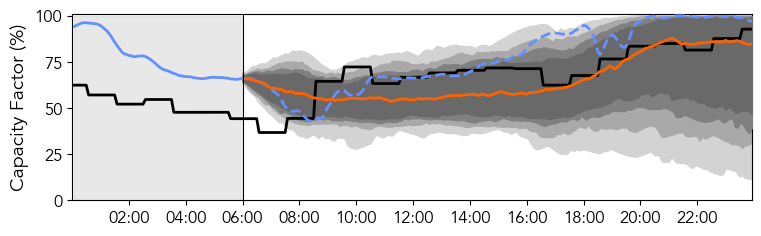

In [17]:
# Calculate confidence intervals from Directional Quantiles
f_median_ext_, _upper, _lower = _fdu.ecdf_confidence_bands(M_int_, alpha_ = [0.1, 0.2, 0.3, 0.4])

_fig, _ax = plt.subplots(figsize = (7.5, 2.25), constrained_layout = True)

_plot_envelop(_ax, _upper, _lower, f_median_ext_, f_, f_hat_, e_bias_, dt_, dx_, interval, 
              color = palette_.loc[3, "ibm"],
              CR = 'CI',
              label = r"$\bar{\mu} (s)$",
              legend_1 = False, 
              legend_2 = False)

# _ax.legend(frameon = False, 
#            loc = (0.1875, .825),
#            fontsize = 12,
#            columnspacing=0.5,
#            handletextpad=0.25,
#            ncol = 5)

plt.savefig(path_to_images + f"/EDF-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

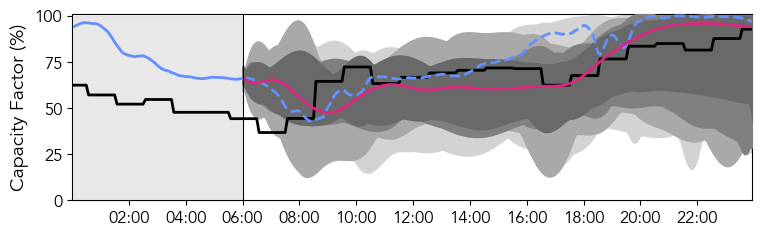

In [18]:
# Samples in each confidence band
depth = 'MBD'
alpha_ = [0.1, 0.2, 0.3, 0.4]

k_ = _get_band_fraction(depth_, alpha_, depth, interval)

f_deepest_ext_, _upper, _lower = _fdu.depth_confidence_bands(_depth, alpha_, k_)

_fig, _ax = plt.subplots(figsize = (7.5, 2.25), constrained_layout = True)

_plot_envelop(_ax, _upper, _lower, f_deepest_ext_, f_, f_hat_, e_bias_, dt_, dx_, interval, 
              CR = 'CR',
              label = r"$\tilde{f} (s)$",
              color = palette_.loc[2, "ibm"],
              legend_1 = False, 
              legend_2 = False)

# _ax.legend(frameon = False, 
#            loc = (0.1875, .825),
#            fontsize = 12,
#            columnspacing=0.5,
#            handletextpad=0.25,
#            ncol = 5)

# plt.savefig(path_to_images + f"/depth-{depth}_{file_name}.pdf", 
#             bbox_inches="tight")

plt.show()

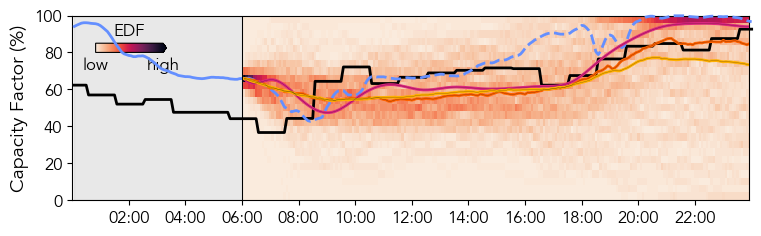

In [19]:
def _plot_density_heatmap(_ax, M_, f_median_, f_deepest_, f_focal_, f_, f_hat_, e_, dx_, dt_, interval, 
                          colorbar = True,
                          legend_1 = True,
                          legend_2 = True):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]
    dt   = dt_[1] - dt_[0]

    Z_ = []
    for i in range(M_.shape[1]):
        a_, b_ = np.histogram(100 * M_[:, i], 
                              bins = 25, 
                              range = (0, 100), 
                              density = True)
        Z_.append(a_)

    Z_     = np.stack(Z_).T
    X_, Y_ = np.meshgrid(dt_[interval:], (b_[1:] + b_[:-1]) / 2.0)

    _cmap = sns.color_palette("rocket_r", as_cmap = True)
    _ax.pcolormesh(X_ + dt, Y_, Z_, cmap = _cmap, alpha = 1.)

    _ax.plot(s_ + dt, 100 * f_median_[1:], 
             c = palette_.loc[3, "ibm"], 
             label = r"$\bar{\mu} (s)$" if legend_2 else None,
             lw = 2, 
             zorder = 10)

    _ax.plot(s_ + dt, 100 * f_median_[1:], 
             c = 'k', 
             lw = .25,
             alpha = 0.5,
             zorder = 11)
    
    _ax.plot(s_ + dt, 100 * f_deepest_[1:], 
             c = palette_.loc[2, "ibm"], 
             label = r"$\bar{f} (s)$" if legend_2 else None,
             lw = 2, 
             zorder = 10)
    
    _ax.plot(s_ + dt, 100 * f_deepest_[1:], 
             c = 'k', 
             lw = .25, 
             alpha = 0.5,
             zorder = 11)
    
    _ax.plot(s_ + dt, 100 * f_focal_[1:], 
             c = palette_.loc[4, "ibm"], 
             label = r"$\tilde{f} (s)$" if legend_2 else None,
             lw = 2, 
             zorder = 10)

    _ax.plot(s_ + dt, 100 * f_focal_[1:], 
             c = 'k', 
             lw = .25, 
             alpha = 0.5,
             zorder = 11)
    
    _ax.plot(tau_ + dt, 100 * f_,
             c = palette_.loc[0, "ibm"],
             zorder = 9,
             lw = 2,
             label = "CF (actual)" if legend_1 else None, 
             clip_on = False)

    _ax.plot(s_ + dt, 100 * f_hat_, 
             c = palette_.loc[0, "ibm"], 
             zorder = 9,
             lw = 2, 
             ls = "--", 
             clip_on = False)

    _ax.plot(dt_ + dt, 100 * e_, 
             c = "k", 
             lw = 2, 
             label = "CF (forecast)" if legend_1 else None, 
             zorder = 8,
             clip_on = False)

    _ax.axvline(dt_[interval - 1] + dt, 
                color = "k", 
                linewidth = 0.75, 
                label = "Event (update)" if legend_1 else None,
                zorder = 10)

    _ax.fill_between(tau_ + dt, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color = "lightgray",
                     alpha = 0.5)
    
    _ax.set_xticks(dt_[24::24], dx_[24::24], rotation = 0)
    _ax.set_ylabel("Capacity Factor (%)", size = 14)

    _ax.tick_params(axis = "both", labelsize = 12)

    _ax.set_ylim(0, 100)
    _ax.set_xlim(dt_[0], dt_[-1])

    if colorbar:
        cbar = fig.colorbar(cm.ScalarMappable(cmap=_cmap),
                            cax = _ax.inset_axes([50, 80, 150, 5], transform=_ax.transData),
                            orientation = "horizontal",
                            extend = "max")
    
        cbar.set_ticks([0, 1], 
                       labels = ["low", "high"], 
                       fontsize = 12)
        
        cbar.ax.tick_params(length=0)
    
        cbar.ax.set_title("EDF", rotation=0)
    
_fig, _ax = plt.subplots(figsize = (7.5, 2.25), constrained_layout = True)

_plot_density_heatmap(_ax, M_, _fdu.f_median_ext_, _fdu.f_deepest_ext_, _fdu.f_focal_ext_,
                      f_, f_hat_, e_bias_, dx_, dt_, interval, 
                      colorbar = True,
                      legend_1 = False,
                      legend_2 = False)

# _ax.legend(frameon = False, 
#            loc = (0.0125, .8),
#            fontsize = 12, 
#            ncol = 3)

plt.savefig(path_to_images + f"/heatmap-{file_name}.pdf", 
            bbox_inches = "tight")

plt.show()

TypeError: 'NoneType' object is not subscriptable

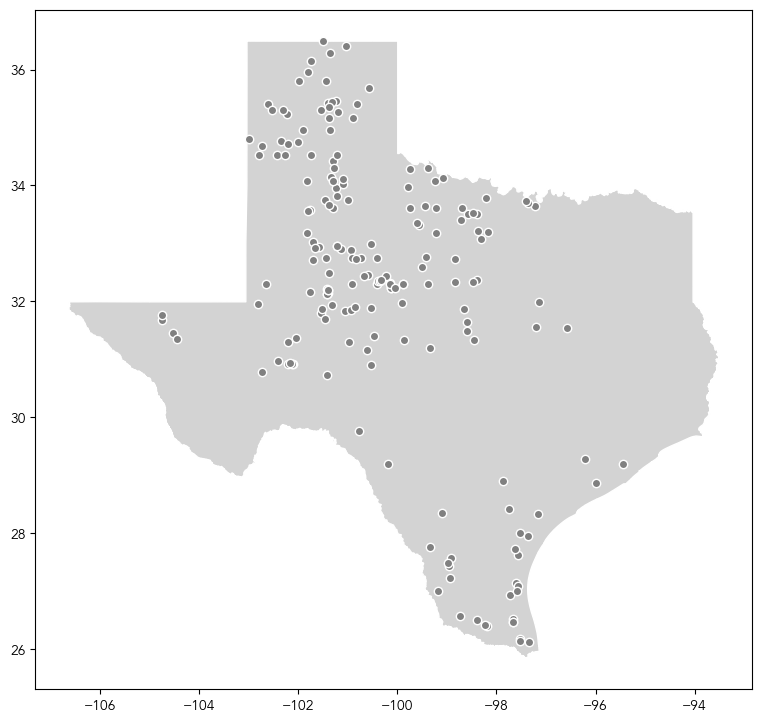

In [20]:
def _plot_frequency_map(_fig, _ax, _TX, x_tr_, x_ts_, x_, 
                        idx_neighbors_, idx_temporal_, idx_spatial_, sigma):

    x_tr_p_, z_tr_p_ = np.unique(x_tr_[idx_neighbors_, :], 
                                 return_counts = True, 
                                 axis = 0)

    _cmap = sns.color_palette("rocket_r", as_cmap=True)
    _norm = plt.Normalize(1, z_tr_p_.max())

    _TX.plot(ax=_ax, 
             facecolor="lightgray", 
             edgecolor="white", 
             zorder=0)

    _ax.plot(x_ts_[:, 0], x_ts_[:, 1],
             c="gray",
             alpha=1,
             ms=6,
             marker="o",
             mec="w",
             ls="none",
             mew=1.0,
             zorder=2, 
             clip_on=False,
             label="No neighboring assets")
    
    _ax.plot(x_[0], x_[1],
             c=_cmap(_norm(z_tr_p_.max() / 2.0)),
             alpha=0.75,
             ms=6,
             ls="none",
             marker="o",
             mec="w",
             mew=1.0,
             zorder=0, 
             clip_on=False,
             label="Neighboring assets")

    _ax.plot(x_[0], x_[1],
             c=_cmap(_norm(z_tr_p_.max() / 4.0)),
             alpha=0.75,
             ms=6,
             ls="none",
             marker="o",
             mec="k",
             mew=1.0,
             zorder=0, 
             clip_on=False,
             label="Selected neighboring assets")

    for i in np.arange(x_tr_p_.shape[0], dtype=int)[np.argsort(z_tr_p_)]:
        if (x_tr_p_[i, 0] != x_[0]) | (x_tr_p_[i, 1] != x_[1]):
            _ax.plot(x_tr_p_[i, 0], x_tr_p_[i, 1],
                     c=_cmap(_norm(z_tr_p_[i])),
                     ms=6,
                     ls="none",
                     marker="o",
                     mec="w",
                     mew=.75,
                     zorder=6, 
                     clip_on=False)
        else:
            _ax.plot(x_tr_p_[i, 0], x_tr_p_[i, 1],
                     c=_cmap(_norm(z_tr_p_[i])),
                     ms=14,
                     ls="none",
                     marker="d",
                     mec="w",
                     mew=1.,
                     zorder=4, 
                     label = 'Asset (update)',
                     clip_on=False)

    x_tr_p_ = np.unique(x_tr_[idx_spatial_, :], axis=0)
    for i in range(x_tr_p_.shape[0]):
        if (x_tr_p_[i, 0] != x_[0]) | (x_tr_p_[i, 1] != x_[1]):
            _ax.plot(x_tr_p_[i, 0], x_tr_p_[i, 1],
                     ms=6,
                     ls="none",
                     marker="o",
                     c = 'none', 
                     mec="k",
                     mew=.75,
                     zorder=7, 
                     clip_on=False)
        else:
            _ax.plot(x_tr_p_[i, 0], x_tr_p_[i, 1],
                     ms=14,
                     ls="none",
                     marker="d",
                     c = 'none', 
                     mec="lime",
                     mew=.75,
                     zorder=5, 
                     #label = 'Asset (update)',
                     clip_on=False)
    
    minx, miny, maxx, maxy = _TX.total_bounds
    X_, Y_ = np.meshgrid(np.linspace(minx, maxx, 1000), 
                         np.linspace(miny, maxy, 1000))

    y_ = np.concatenate([X_.flatten()[:, np.newaxis], 
                                             Y_.flatten()[:, np.newaxis]], axis = 1)
    Z_ = _fdu._haversine_dist(x_, y_).reshape(X_.shape)

    contours = _ax.contour(X_, Y_, Z_, 
                           levels = [sigma], 
                           colors = 'k', 
                           linewidths = 0.5, 
                           linestyles = 'dashed', zorder = 11)

    cbar = _fig.colorbar(cm.ScalarMappable(cmap = _cmap),
                         cax=_ax.inset_axes([-97.75, 35.5, 2.0, 0.25], transform = _ax.transData),
                         orientation="horizontal")

    cbar.set_ticks([0, 1], 
                   labels=[1, int(z_tr_p_.max())], 
                   fontsize=14)
    
    cbar.ax.tick_params(length=0)
    
    cbar.ax.set_title("Neighbors", 
                      rotation = 0, 
                      fontsize = 12)
    
    _ax.set_axis_off()


fig, _ax = plt.subplots(figsize = (7.5, 7.5), constrained_layout = True)


_plot_frequency_map(_fig, _ax, _TX, X_tr_, x_ts_, 
                    _fdu.x_,
                    _fdu.idx_neighbors_,
                    _fdu.idx_temporal_, 
                    _fdu.idx_spatial_, 
                    _fdu.sigma)

_ax.legend(frameon=False,
           bbox_to_anchor=(0.475, 0.25),
           ncol=1,
           fontsize=12)

# plt.savefig(path_to_images + f"/spatial_neiboring_assets-{file_name}.pdf", 
#             bbox_inches="tight")

plt.show()

 /var/folders/0c/ffx2kgyn7xq4krqrpsv67l3m0000gn/T/ipykernel_97797/827337491.py:96: UserWarning:constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
 /var/folders/0c/ffx2kgyn7xq4krqrpsv67l3m0000gn/T/ipykernel_97797/827337491.py:96: UserWarning:constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning:constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.


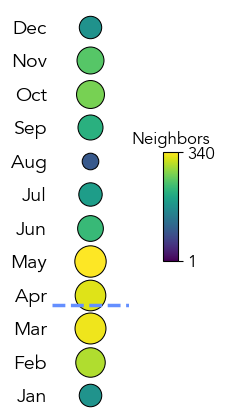

In [21]:
def _scenarios_frequency_dates(_ax, 
                               idx_neighbors_, idx_temporal_, idx_spatial_, t_tr_, t_ts, 
                               scale = 2.5,
                               colorbar = True):

    _date     = datetime.datetime.strptime(t_ts, "%Y-%m-%d %H:%M:%S")
    m_a       = _date.timetuple().tm_mon - 1
    day       = _date.timetuple().tm_mday - 1
    _, n_days = calendar.monthrange(_date.year, m_a + 1)

    m_tr_ = np.stack([datetime.datetime.strptime(t_tr_[i], "%Y-%m-%d %H:%M:%S").timetuple().tm_mon - 1
                      for i in range(t_tr_.shape[0])])

    month_name_ = ["Jan", "Feb", "Mar", "Apr",
                   "May", "Jun", "Jul", "Aug",
                   "Sep", "Oct", "Nov", "Dec"]
    
    months_, counts_ = np.unique(m_tr_[idx_neighbors_], return_counts=True)

    counts_1_ = np.zeros(12)
    for month, count in zip(months_, counts_):
        counts_1_[month] = count
    
    months_, counts_ = np.unique(m_tr_[idx_temporal_], return_counts=True)

    counts_2_ = np.zeros(12)
    for month, count in zip(months_, counts_):
        counts_2_[month] = count

    months_ = np.arange(12, dtype = int)
    jitter_strength = 0.5
    x_ = 0. + np.random.normal(0, jitter_strength, size=months_.shape[0])*0.

    counts_2_p_ = counts_2_.copy()
    counts_2_p_[counts_2_ == 0] = np.nan

    _cmap = sns.color_palette("viridis", as_cmap=True)
    _cmap.set_bad(color= 'lightgray')  # RGBA: transparent
    _norm = plt.Normalize(1, counts_2_.max())
    
    for i in range(x_.shape[0]):
        # Plot
        _ax.scatter(x_[i], months_[i], 
                    s=counts_1_[i]*scale,
                    color=_cmap(_norm(counts_2_p_[i])),
                    ec='k',
                    vmin=1, 
                    vmax=counts_2_.max(),
                    lw=0.75, 
                    clip_on = False,
                    zorder = 6)

    _ax.set_xlim(-5, 5)

    _ax.set_xticks(x_, []*len(x_))
        
    _ax.set_yticks(np.arange(len(month_name_), dtype=int), month_name_,
                   size=14)
    
    _ax.tick_params(axis='y', length=0)
    _ax.tick_params(axis='x', length=0)

    _ax.axhline(m_a + day/n_days, 
                color=palette_.loc[0, "ibm"], 
                ls = '--',
                lw=2.5, 
                zorder=6)
    
    cbar = _fig.colorbar(cm.ScalarMappable(cmap = _cmap),
                         cax=_ax.inset_axes([7.5, 4, 1.5, 3.25], transform = _ax.transData))

    cbar.set_ticks([0, 1], 
                   labels=[1, int(counts_2_.max())], 
                   fontsize=12)
        
    cbar.ax.set_title("Neighbors", 
                      rotation = 0, 
                      fontsize = 12)
    _ax.set_xlim(-4, 4)

    sns.despine(left=True, 
                bottom=True) 

fig, _ax = plt.subplots(figsize = (1, 5), constrained_layout = True)


_scenarios_frequency_dates(_ax,
                           _fdu.idx_neighbors_, 
                           _fdu.idx_temporal_, 
                           _fdu.idx_spatial_, 
                           T_tr_[:, interval], 
                           _fdu.date, 
                           scale = 1.5,
                           colorbar = True)

plt.savefig(path_to_images + f"/temporal_neiboring_assets-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

AttributeError: 'NoneType' object has no attribute 'shape'

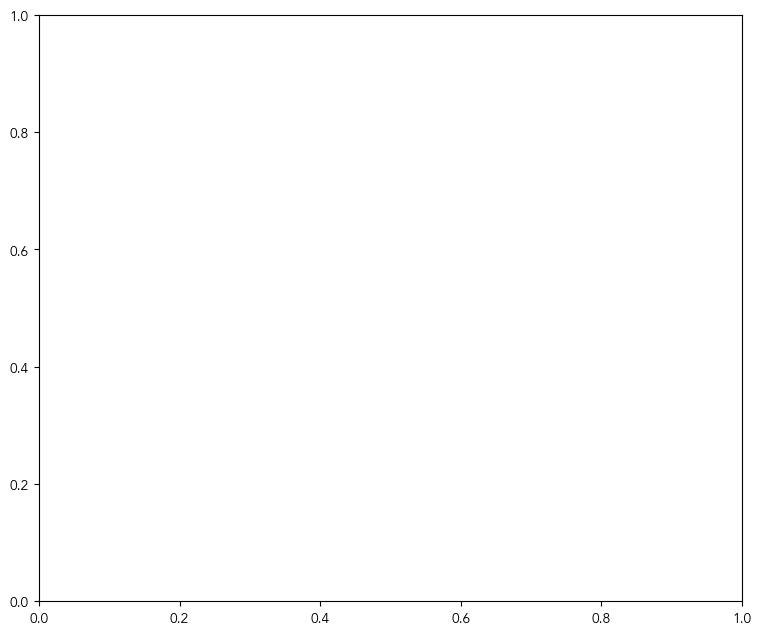

In [22]:
def _selected_scenarios_heatmap(_ax, 
                                _haversine_dist, 
                                idx_, 
                                d_h_,
                                x_,
                                t_tr_, 
                                x_ts_, 
                                t_ts,
                                colorbar = True):
        
    N     = 12
    delta = 15
    print(x_.shape, x_ts_.shape)
    d_      = _haversine_dist(x_, x_ts_)
    d_sort_ = np.sort(d_)[:-7]

    tops_      = [int((i + 1) * delta) for i in range(N)]
    intervals_ = [d_sort_[i - 1] for i in tops_]

    _date     = datetime.datetime.strptime(t_ts, "%Y-%m-%d %H:%M:%S")
    m_a       = _date.timetuple().tm_mon - 1
    day       = _date.timetuple().tm_mday - 1
    _, n_days = calendar.monthrange(_date.year, m_a + 1)

    m_tr_ = np.stack([datetime.datetime.strptime(t_tr_[i], "%Y-%m-%d %H:%M:%S").timetuple().tm_mon - 1
                      for i in range(t_tr_.shape[0])])

    K        = 0
    heatmap_ = np.zeros((N + 1, m_tr_.max() + 1))
    for d_h, m in zip(d_h_[idx_], m_tr_[idx_]):
        heatmap_[np.searchsorted(intervals_, d_h), m] += 1
        K += 1
        
    h_max = int(heatmap_.max())
    heatmap_[heatmap_ == 0.] = np.nan

    _cmap = sns.color_palette("Spectral_r", as_cmap=True)
    _cmap.set_bad(color= 'lightgray')  # RGBA: transparent
    
    month_ = ["Jan",
              "Feb",
              "Mar",
              "Apr",
              "May",
              "Jun",
              "Jul",
              "Aug",
              "Sep",
              "Oct",
              "Nov",
              "Dec"]

    _ax.matshow(heatmap_[:-1, :], 
                cmap=_cmap, 
                vmin=0.0, 
                extent=[0, 12, N, 0])

    _ax.set_xticks(range(len(month_)), [] * len(month_))
    _ax.set_yticks(range(len(tops_)), [] * len(tops_))

    _ax.set_ylabel("Top Spatial Neighboring Asset", size=18)
    
    # if xlabel:
    #     _ax.set_xlabel("Month", size=16)
    _ax.xaxis.set_label_position("top")

    _ax.set_xticks(np.arange(len(month_), dtype=int) + 0.5, month_,
                   rotation=45,
                   minor=True,
                   size=18)

    _ax.set_yticks(np.arange(len(tops_), dtype=int) + 0.5, tops_,
                   minor=True,
                   size=16)

    _ax.tick_params(which="major", 
                    bottom=False, 
                    left=False, 
                    top=False)
    
    _ax.tick_params(which="minor", 
                    bottom=False)
    
    _ax.grid(which="major", 
             color="k", 
             linestyle="-", 
             linewidth=1.5)

    _ax.axvline(m_a + day/n_days, 
                color=palette_.loc[0, "ibm"], 
                ls = '--',
                lw=3, 
                zorder=6)
    
    if colorbar:
        cbar = _fig.colorbar(cm.ScalarMappable(cmap = _cmap),
                             cax = _ax.inset_axes([3.5, 13.125, 5., 0.5], transform = _ax.transData),
                             orientation="horizontal")
    
        cbar.set_ticks([0, 1], 
                       labels=[1, h_max], 
                       fontsize=16)
        
        cbar.ax.tick_params(length=0)
        
        cbar.ax.set_title("Neighbors", 
                          rotation = 0, 
                          fontsize = 16)

fig, _ax = plt.subplots(figsize = (7.5, 6.25), constrained_layout = True)

_selected_scenarios_heatmap(_ax, 
                            _fdu._haversine_dist,
                            _fdu.idx_neighbors_, 
                            _fdu.d_h_,
                            _fdu.x_,
                            T_tr_[:, interval], 
                            x_ts_, 
                            _fdu.date,
                            colorbar = True)

plt.savefig(path_to_images + f"/seasonly_neiboring_assets-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

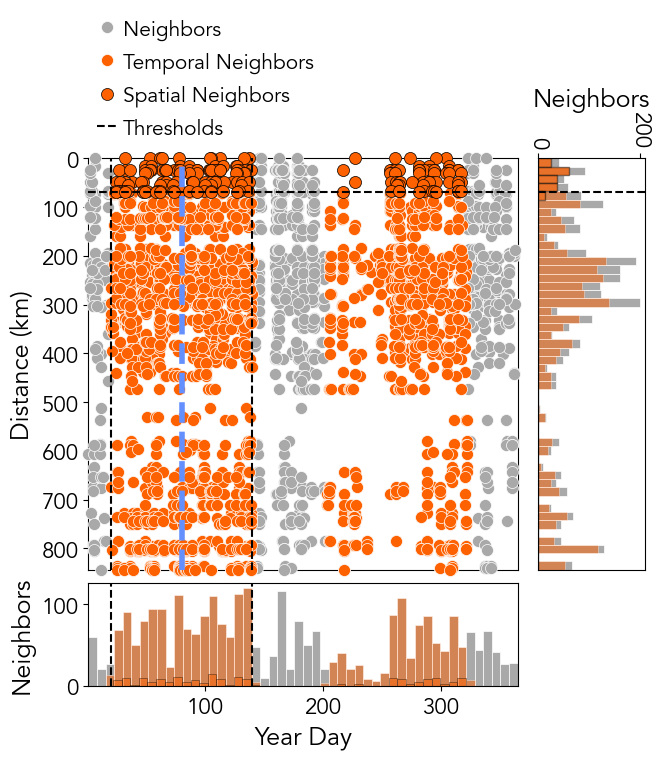

In [42]:
def _check_limit(x):
    if x > 365:
        x = x - 365
    if x < 1:
        x = x + 365
    return x
        
def _plot_scenario_filtering(_ax, 
                             idx_neighbors_, 
                             idx_temporal_,
                             idx_spatial_,
                             d_h_,
                             t_tr_, 
                             t_ts,
                             sigma, 
                             gamma, 
                             gamma_prime):
    
    _ax.scatter(t_tr_[idx_neighbors_], d_h_[idx_neighbors_],
                s=75,
                c="darkgray",
                lw=0.5,
                edgecolor="w",
                clip_on=False,
                zorder=4,
                label="Neighbors")

    _ax.scatter(t_tr_[idx_temporal_], d_h_[idx_temporal_],
                s=75,
                c=palette_.loc[3, "ibm"],
                lw=0.5,
                edgecolor="w",
                clip_on=False,
                zorder=5,
                label="Temporal Neighbors")

    _ax.scatter(t_tr_[idx_spatial_], d_h_[idx_spatial_],
                s=75,
                c=palette_.loc[3, "ibm"],
                lw=0.5,
                edgecolor="k",
                clip_on=False,
                zorder=5,
                label="Spatial Neighbors")

    _ax.axvline(t_ts, 
                color=palette_.loc[0, "ibm"], 
                ls = '--',
                lw=4, 
                zorder=6)

    if gamma_prime != 0:  
        _ax.axvline(_check_limit(t_ts + gamma), 
                    c="k", 
                    ls='--', 
                    lw=1.5, 
                    zorder=10)
                    
        _ax.axvline(_check_limit(t_ts - gamma), 
                    c="k", 
                    ls='--', 
                    lw=1.5, 
                    zorder=10, 
                    label="Thresholds")
    
    if sigma != 0:
        _ax.axhline(sigma, 
                    c="k", 
                    ls='--', 
                    lw=1.5, 
                    zorder=10)

    #_ax.set_ylabel(r"$|| \mathbf{x}_\star - \mathbf{x}_n ||_\mathrm{H}$", size=14)
    #_ax.set_xlabel(r"$|| d_\star - d_n ||_\mathrm{p}$", size=16)
    #_ax.set_xlabel(r"Year Day", size=16)
    _ax.set_ylabel(r"Distance (km)", size=18)
    _ax.set_xlim(1, 365)
    _ax.set_ylim(0, d_h_.max())
    _ax.set_xticks([], [])

    _ax.tick_params(axis="both", 
                    labelsize=16)

    _ax.set_xlim(1, 365)
    _ax.invert_yaxis()


def _plot_dates_histogram(_ax, 
                          idx_neighbors_, 
                          idx_temporal_,
                          idx_spatial_,
                          d_h_,
                          t_tr_, 
                          t_ts,
                          gamma, 
                          gamma_prime):

    _ax.hist(t_tr_[idx_neighbors_], 
             bins=50, 
             range=(1, 365), 
             color="darkgray", 
             edgecolor="w", 
             lw=0.5)

    _ax.hist(t_tr_[idx_temporal_],
             bins=50,
             range=(1, 365),
             alpha=0.5,
             color=palette_.loc[3, "ibm"],
             edgecolor="w",
             lw=0.5)

    _ax.hist(t_tr_[idx_spatial_],
             bins=50,
             range=(0, 365),    
             alpha=0.5,
             color=palette_.loc[3, "ibm"],
             edgecolor="k",
             lw=0.5)
    
    if gamma_prime != 0:  
        _ax.axvline(_check_limit(t_ts - gamma), 
                    c="k", 
                    ls="--", 
                    lw=1.5, 
                    zorder=2, 
                    label="d: day")
        
        _ax.axvline(_check_limit(t_ts + gamma), 
                    c="k", 
                    ls="--", 
                    lw=1.5, 
                    zorder=2, 
                    label="d: day")
        
    _ax.set_xlabel(r"Year Day", size=18)
    _ax.set_ylabel(r"Neighbors", size=18)
    _ax.set_xlim(1, 365)
    _ax.tick_params(axis="both", labelsize=16)
    #_ax.set_xticks([], [])

def _plot_distance_histogram(_ax, 
                             idx_neighbors_, 
                             idx_temporal_, 
                             idx_spatial_, 
                             d_h_, 
                             sigma):
    
    d_max = d_h_.max()
    
    _ax.hist(d_h_[idx_neighbors_], 
             bins=50, 
             range=(0, d_max), 
             color="darkgray", 
             edgecolor="w", 
             lw=0.5, 
             orientation="horizontal")
    
    _ax.hist(d_h_[idx_temporal_],
             bins=50,
             range=(0, d_h_.max()),    
             alpha=0.5,
             color=palette_.loc[3, "ibm"],
             edgecolor="w",
             lw=0.5, 
             orientation="horizontal")

    _ax.hist(d_h_[idx_spatial_],
             bins=50,
             range=(0, d_h_.max()),    
             alpha=0.5,
             color=palette_.loc[3, "ibm"],
             edgecolor="k",
             lw=1, 
             orientation="horizontal")

    if sigma != 0:
        _ax.axhline(sigma, 
                    c="k", 
                    ls='--', 
                    lw=1.5, 
                    zorder=10)

    _ax.xaxis.set_label_position("top")
    _ax.xaxis.tick_top()
    #_ax.set_xlabel(r"Distance (km)", size=16)
    _ax.set_xlabel(r"Neighbors", size=18)
    _ax.set_ylim(0, d_max)
    _ax.tick_params(axis="both", labelsize=16, rotation = 270)
    _ax.set_yticks([], [])
    _ax.invert_yaxis()
    #_ax.legend(frameon=False, ncol=1, fontsize = 12)

fig, _ax = plt.subplot_mosaic([["A", "B"], 
                               ["C", "."]],
                              figsize = (6.5, 7.5),
                              layout = "constrained",
                              gridspec_kw = dict(width_ratios  = (1, .25), 
                                                 height_ratios = (1, .25)))


_plot_scenario_filtering(_ax["A"], 
                         _fdu.idx_neighbors_, 
                         _fdu.idx_temporal_,
                         _fdu.idx_spatial_,
                         _fdu.d_h_,
                         t_tr_, 
                         t_ts_[day],
                         _fdu.sigma,
                         _fdu.gamma, 
                         _fdu.gamma_prime )

_plot_distance_histogram(_ax["B"], 
                         _fdu.idx_neighbors_,
                         _fdu.idx_temporal_,
                         _fdu.idx_spatial_,
                         _fdu.d_h_,
                         _fdu.sigma)

_plot_dates_histogram(_ax["C"], 
                      _fdu.idx_neighbors_, 
                      _fdu.idx_temporal_,
                      _fdu.idx_spatial_,
                      _fdu.d_h_,
                      t_tr_, 
                      t_ts_[day], 
                      _fdu.gamma,
                      _fdu.gamma_prime)

_ax["A"].legend(frameon=False, 
                ncol=1, 
                columnspacing=0.625,
                handletextpad=0.25,
                loc = (0., 1.025), 
                fontsize = 15)

plt.savefig(path_to_images + f"/kNN_frequency-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

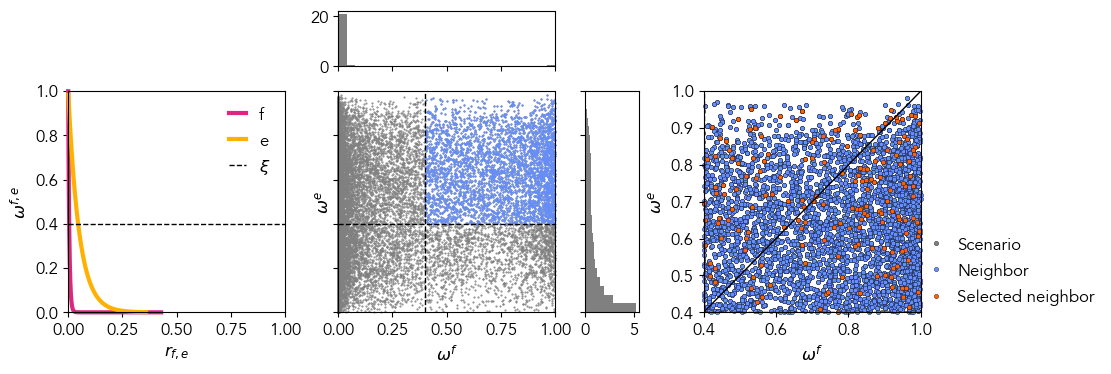

In [44]:
def _plot_density_threshold(_ax, 
                            d_f_, 
                            d_e_, 
                            w_f_, 
                            w_e_, 
                            xi):

    _ax.plot(d_f_[np.argsort(d_f_)], w_f_[np.argsort(d_f_)],
             c=palette_.loc[2, "ibm"],
             lw=3,
             label="f", 
             clip_on = False)

    _ax.plot(d_e_[np.argsort(d_e_)], w_e_[np.argsort(d_e_)],
             c=palette_.loc[4, "ibm"],
             lw=3,
             label="e", 
             clip_on = False)

    _ax.axhline(xi, 
                ls="--", 
                color="k", 
                lw=1.0, 
                label=r"$\xi$", 
                zorder=10)
    
    _ax.set_ylabel(r"$\omega^{f,e}$", size=12)
    _ax.set_xlabel(r"$r_{f,e}$", size=12)
    
    _ax.tick_params(axis="both", 
                    labelsize=12)
    
    _ax.legend(frameon=False, 
               fontsize=12)

    _ax.set_ylim(0, 1)
    _ax.set_xlim(0, 1)

    
def _plot_fneighborhood(_ax, 
                        _ax_top, 
                        _ax_left, 
                        idx_neighbors_, 
                        w_f_, 
                        w_e_, 
                        xi):

    _ax.scatter(w_f_, w_e_, 
                color="gray", 
                s=0.25, 
                zorder=1, 
                clip_on = False)

    _ax.scatter(w_f_[idx_neighbors_], w_e_[idx_neighbors_], 
                c=palette_.loc[0, "ibm"],
                s=0.25, 
                zorder=2, 
                clip_on = False)

    _ax.axhline(xi, 
                ls="--", 
                color="k", 
                lw=1.0, 
                label=r"$\xi$", 
                zorder=10)

    _ax.axvline(xi, 
                ls="--", 
                color="k", 
                lw=1.0, 
                label=r"$\xi$", 
                zorder=10)

    _ax.set_ylabel(r"$\omega^{e}$", size=12)
    _ax.set_xlabel(r"$\omega^{f}$", size=12)
    
    _ax.tick_params(axis="both", labelsize=12)

    _ax.set_ylim(0, 1)
    _ax.set_xlim(0, 1)

    _ax_top.hist(w_f_, 
                 bins=25, 
                 range=(0, 1),
                 color="gray", 
                 density=True)
    
    _ax_top.tick_params(axis="both", 
                        labelsize=12)
    
    _ax_top.set_xlim(0, 1)

    _ax_left.hist(w_e_, 
                  bins=25, 
                  range=(0, 1),
                  color="gray", 
                  density=True, 
                  orientation="horizontal")
    
    _ax_left.set_ylim(0, 1)

    _ax_left.tick_params(axis="both", 
                         labelsize=12)

    _ax.tick_params(axis="y", 
                    labelleft=False)

    _ax_top.tick_params(axis="x", 
                        labelbottom=False)
    
    _ax_left.tick_params(axis="y", 
                         labelleft=False)
    
def _plot_selection(_ax, 
                    idx_neighbors_, 
                    idx_temporal_,
                    idx_spatial_, 
                    w_f_, 
                    w_e_, 
                    w_, 
                    xi):

    _ax.scatter(w_f_, w_e_, 
                c="gray", 
                s=10, 
                alpha=1.0,
                lw=0.25, 
                ec="k", 
                label="Scenario", 
                clip_on = True)

    _ax.scatter(w_f_[idx_neighbors_], w_e_[idx_neighbors_],
                c=palette_.loc[0, "ibm"],
                s=10,
                alpha=1.0,
                lw=0.25,
                ec="k",
                label="Neighbor",
                clip_on = False)

    _ax.scatter(w_f_[idx_spatial_], w_e_[idx_spatial_],
                c=palette_.loc[3, "ibm"],
                s=10,
                lw=0.25,
                ec="k",
                alpha=1.0,
                label="Selected neighbor", 
                clip_on = False)

    _ax.axline((1, 1), 
               slope=1, 
               lw=1, 
               c="k")
    
    _ax.set_ylabel(r"$\omega^{e}$", size=12)
    _ax.set_xlabel(r"$\omega^{f}$", size=12)
    
    _ax.tick_params(axis="both", 
                    labelsize=12)
    
    _ax.set_xlim(xi, 1)
    _ax.set_ylim(xi, 1)
    
    _ax.axhline(xi, 
                ls="--", 
                color="k", 
                lw=1.0, 
                zorder=10)
    
    _ax.axvline(xi, 
                ls="--", 
                color="k", 
                lw=1.0, 
                zorder=10)
    
    _ax.legend(frameon=False, 
               fontsize=12, 
               ncol=1, 
               loc=(1., 0.))

  
fig, _ax = plt.subplot_mosaic([[".", ".", "e", ".", ".", "."],
                               ["A", "A", "B", "f", "C", "C"],
                               ["A", "A", "B", "f", "C", "C"]],
                               figsize = (11, 3.625),
                               layout = "constrained",
                               gridspec_kw = dict(width_ratios  = (2, 2, 4, 1, 2, 2), 
                                                  height_ratios = (1, 2, 2)))

_plot_density_threshold(_ax["A"], 
                        _fdu.d_f_, 
                        _fdu.d_e_, 
                        _fdu.w_f_, 
                        _fdu.w_e_, 
                        _fdu.xi)

_plot_fneighborhood(_ax["B"], 
                    _ax["e"], 
                    _ax["f"], 
                    _fdu.idx_neighbors_, 
                    _fdu.w_f_, 
                    _fdu.w_e_, 
                    _fdu.xi)

_plot_selection(_ax["C"],  
                _fdu.idx_neighbors_, 
                _fdu.idx_temporal_, 
                _fdu.idx_spatial_, 
                _fdu.w_f_, 
                _fdu.w_e_, 
                _fdu.w_, 
                _fdu.xi)

plt.savefig(path_to_images + f"/fneighbor-{file_name}.pdf", 
            bbox_inches = "tight")

plt.show()

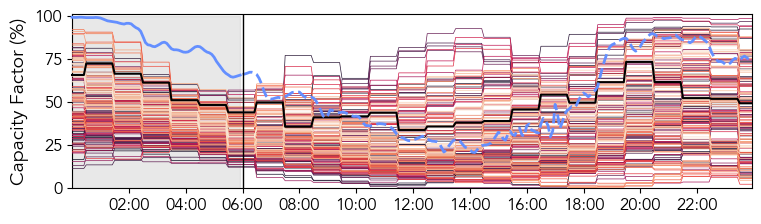

In [46]:
def _plot_forecasts(_ax, 
                    E_tr_, 
                    w_, 
                    idx_, 
                    f_, 
                    f_hat_, 
                    e_, 
                    dx_, 
                    dt_, 
                    interval, 
                    legend = False):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]

    z_   = (w_ - w_[idx_].min()) / (w_[idx_].max() - w_[idx_].min())
    idx_ = idx_[np.argsort(w_[idx_])]

    _cmap = sns.color_palette("rocket", as_cmap=True)
    _norm = plt.Normalize(0, 1)

    _ax.plot([], [], 
             lw = 0.75,
             label=r"$E_{\star} \left([\tau, s]\right)$", 
             c="k")
    
    _ax.plot(tau_, 100. * f_,
             c=palette_.loc[0, "ibm"],
             clip_on=False,
             zorder=10,
             #label="CF (ac)",
             lw=2)

    _ax.plot(s_, 100. * f_hat_,
             c=palette_.loc[0, "ibm"],
             clip_on=False,
             zorder=10,
             lw=2,
             ls="--")

    _ax.plot(dt_, 100. * e_, 
             clip_on=False, 
             lw=1.5, 
             zorder=9, 
             #label="CF (fc)", 
             c="k")

    for i, j in zip(idx_, range(idx_.shape[0])):
        _ax.plot(dt_, 100 * E_tr_[i, :], 
                 #c=_cmap(_norm(z_[i])), 
                 c=_cmap(_norm(j/idx_.shape[0])), 
                 lw=.5, 
                 zorder=8)

    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color="lightgray",
                     alpha=0.5,
                     zorder=1)
    
    _ax.axvline(dt_[interval], 
                color="k", 
                lw=1.0, 
                zorder=11)
    
    _ax.set_xticks(dt_[24::24], dx_[24::24], rotation=0)

    _ax.set_ylim(0.0, 101)
    _ax.set_xlim(dt_[0], dt_[-1])
    _ax.set_ylabel("Capacity Factor (%)", size=14)

    _ax.tick_params(axis="both", 
                    labelsize=12)

_fig, _ax = plt.subplots(figsize = (7.5, 2.125), constrained_layout = True)

_plot_forecasts(_ax, 
                E_tr_bias_, 
                _fdu.w_, 
                _fdu.idx_spatial_, 
                f_, 
                f_hat_, 
                e_bias_, 
                dx_, 
                dt_, 
                interval)

# _ax.legend(loc=(0.5, 0.8),
#            frameon=False, 
#            fontsize=12, 
#            ncol=1)

plt.savefig(path_to_images + f"/dayahead_neighbors-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

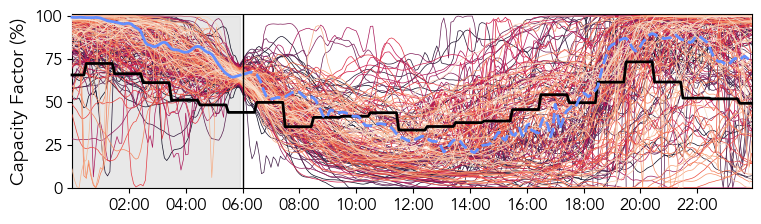

In [47]:
def _plot_neighbors(_ax, 
                    F_tr_, 
                    w_, 
                    idx_, 
                    f_, 
                    f_hat_, 
                    e_, 
                    dx_, 
                    dt_, 
                    interval):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]

    z_   = (w_ - w_[idx_].min()) / (w_[idx_].max() - w_[idx_].min())
    idx_ = idx_[np.argsort(w_[idx_])]

    _cmap = sns.color_palette("rocket", as_cmap=True)
    _norm = plt.Normalize(0., 1.)

    _ax.plot([], [], 
             lw = 0.75,
             label=r"$\mathcal{F}_{\star} \left([\tau, s] \right)$", 
             c="k")
    
    _ax.plot(tau_, 100 * f_, 
             c=palette_.loc[0, "ibm"], 
             zorder=10, 
             #label="CF (ac)", 
             lw=2, 
             clip_on = False)

    _ax.plot(s_, 100 * f_hat_, 
             c=palette_.loc[0, "ibm"], 
             zorder=10, 
             lw=2, 
             ls="--", 
             clip_on = False)

    _ax.plot(dt_, 100 * e_, 
             lw=2, 
             zorder=9, 
             #label="CF (fc)", 
             c="k", 
             clip_on = False)

    for i, j in zip(idx_, range(idx_.shape[0])):
        _ax.plot(dt_, 100 * F_tr_[i, :], 
                 c=_cmap(_norm(j/idx_.shape[0])), 
                 #c=_cmap(_norm(z_[i])), 
                 lw=.5, 
                 zorder=8)

    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color="lightgray",
                     alpha=0.5,
                     zorder=1)

    _ax.axvline(dt_[interval], 
                color="k", 
                lw=1.0, 
                zorder=11)
    
    _ax.set_xticks(dt_[24::24], dx_[24::24], rotation=0)
    _ax.set_ylim(0.0, 101)
    _ax.set_xlim(dt_[0], dt_[-1])
    _ax.set_ylabel("Capacity Factor (%)", size=14)

    _ax.tick_params(axis="both", 
                    labelsize=12)

_fig, _ax = plt.subplots(figsize = (7.5, 2.125), constrained_layout = True)

_plot_neighbors(_ax, 
                F_tr_, 
                _fdu.w_, 
                _fdu.idx_spatial_, 
                f_, 
                f_hat_, 
                e_bias_, 
                dx_, 
                dt_, 
                interval)

# _ax.legend(loc=(0.5, 0.8),
#            frameon=False, 
#            fontsize=12, 
#            ncol=1)

plt.savefig(path_to_images + f"/partial_neighbors-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

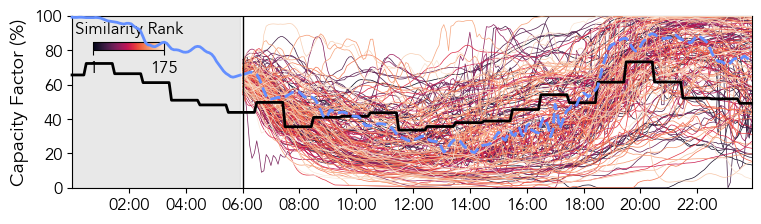

In [49]:
def _plot_updates(_fig, 
                  _ax, 
                  M_, 
                  f_, 
                  f_hat_, 
                  e_, 
                  w_, 
                  idx_, 
                  dx_, 
                  dt_, 
                  interval):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]
    z_   = (w_ - w_[idx_].min()) / (w_[idx_].max() - w_[idx_].min())
    
    w_selected_ = w_[idx_]
    
    idx_w_ = np.argsort(w_selected_)
    idx_   = idx_[idx_w_]
    
    _cmap = sns.color_palette("rocket", as_cmap=True)
    _norm = plt.Normalize(0., 1)

    _ax.plot([], [], 
             lw = 0.75,
             label=r"$\hat{\mu}_i(s)$", 
             c="k")

    _ax.plot(tau_, 100.0 * f_,
             c=palette_.loc[0, "ibm"],
             zorder=10,
             #label="CF (ac)",
             clip_on=False,
             lw=2)

    _ax.plot(s_, 100.0 * f_hat_,
             c=palette_.loc[0, "ibm"],
             zorder=10,
             lw=2,
             clip_on=False,
             ls="--")

    _ax.plot(dt_, 100.0 * e_, 
             lw=2, 
             zorder=9, 
             #label="CF (fc)", 
             clip_on=False, 
             c="k")

    for i, j in zip(idx_, range(idx_.shape[0])):
        _ax.plot(dt_[interval:], 100 * M_[j, :],
                 #c=_cmap(_norm(z_[i])), 
                 c=_cmap(_norm(j/idx_.shape[0])), 
                 lw=0.5, 
                 zorder=8)
        
    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color="lightgray",
                     alpha=0.5,
                     zorder=1)

    _ax.axvline(dt_[interval], 
                color="k", 
                lw=1.0, 
                #label="Event (update)", 
                zorder=11)
    
    _ax.set_xticks(dt_[24::24], dx_[24::24], rotation=0)
    # ax_[2].set_yticks(size = 12)
    _ax.set_ylim(0.0, 100.0)
    _ax.set_xlim(dt_[0], dt_[-1])
    _ax.set_ylabel("Capacity Factor (%)", size=14)
    
    _ax.tick_params(axis="both", 
                    labelsize=12)

    cbar = _fig.colorbar(cm.ScalarMappable(_norm, _cmap),
                         cax=_ax.inset_axes([45, 80, 150, 5], transform=_ax.transData),
                         orientation="horizontal")

    cbar.set_ticks([0, 1], 
                   labels=[1, M_.shape[0]], 
                   size=12)
    
    #cbar.ax.tick_params(length=0)
    
    cbar.ax.set_title("Similarity Rank", 
                      rotation=0, 
                      size=12)

_fig, _ax = plt.subplots(figsize = (7.5, 2.125), constrained_layout = True)

_plot_updates(_fig, 
              _ax, 
              M_, 
              f_, 
              f_hat_, 
              e_bias_, 
              _fdu.w_, 
              _fdu.idx_spatial_, 
              dx_, 
              dt_, 
              interval)

# _ax.legend(loc=(0.5, 0.8),
#            frameon=False, 
#            fontsize=12, 
#            ncol=1)

plt.savefig(path_to_images + f"/dynamic_update_neighbors-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

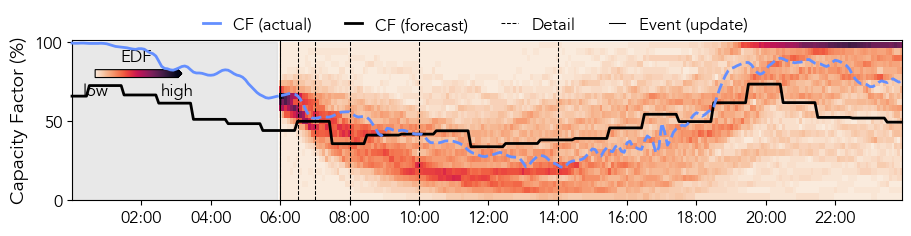

In [51]:
def _plot_heatmap_slices(_fig, 
                         _ax, 
                         M_, 
                         f_, 
                         f_hat_, 
                         e_, 
                         dx_, 
                         dt_, 
                         slices_,
                         interval, 
                         colorbar = True):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]

    Z_ = []
    for i in range(M_.shape[1]):
        a_, b_ = np.histogram(100.0 * M_[:, i], 
                              bins=25, 
                              range=(0, 100), 
                              density=True)
        Z_.append(a_)

    Z_ = np.stack(Z_).T
    X_, Y_ = np.meshgrid(dt_[interval:], (b_[1:] + b_[:-1]) / 2.0)

    _cmap = sns.color_palette("rocket_r", as_cmap=True)
    _ax.pcolormesh(X_, Y_, Z_, cmap =_cmap)

    _ax.plot(tau_, 100 * f_,
             c=palette_.loc[0, "ibm"],
             clip_on=False,
             lw=2.0,
             label="CF (actual)", 
             zorder = 9)

    _ax.plot(s_, 100 * f_hat_, 
             c=palette_.loc[0, "ibm"], 
             clip_on=False, 
             lw=2.0, 
             ls="--", 
             zorder = 9)

    _ax.plot(dt_, 100 * e_, 
             c="k", 
             lw=2.0, 
             label="CF (forecast)", 
             clip_on=False, 
             zorder = 8)
    
    _ax.axvline(dt_[interval], 
                color="k", 
                lw=0.75, 
                ls="--", 
                label="Detail")

    for slice in slices_:
        _ax.axvline(dt_[interval + slice], 
                    color="k", 
                    lw=0.75, 
                    ls="--")

    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color="lightgray",
                     alpha=0.5)

    _ax.axvline(dt_[interval], 
                color="k", 
                label="Event (update)",
                linewidth=0.75, 
                zorder = 11)
    
    _ax.set_xticks(dt_[24::24], dx_[24::24], rotation=0)
    _ax.set_ylabel("Capacity Factor (%)", size=14)

    _ax.tick_params(axis="both", labelsize=12)

    _ax.set_ylim(0, 101)
    _ax.set_xlim(dt_[0], dt_[-1])

    if colorbar:
        cbar = _fig.colorbar(cm.ScalarMappable(cmap=_cmap),
                             cax=_ax.inset_axes([40, 77.5, 150, 5], transform=_ax.transData),
                             orientation="horizontal",
                             extend="max")
    
        cbar.set_ticks([0, 1], labels=["low", "high"], fontsize = 12)
        cbar.ax.tick_params(length=0)
    
        cbar.ax.set_title("EDF", rotation=0)

slices_ = [6, 12, 24, 48, 96]

_fig, _ax = plt.subplots(figsize = (9, 2.25), constrained_layout = True)

_plot_heatmap_slices(_fig, 
                     _ax, 
                     _fdu.M_, 
                     f_, 
                     f_hat_, 
                     e_bias_, 
                     dx_, 
                     dt_, 
                     slices_,
                     interval)

_ax.legend(loc=(0.15, 1),
           frameon=False, 
           fontsize=12, 
           ncol=4)

plt.savefig(path_to_images + f"/heatmap-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

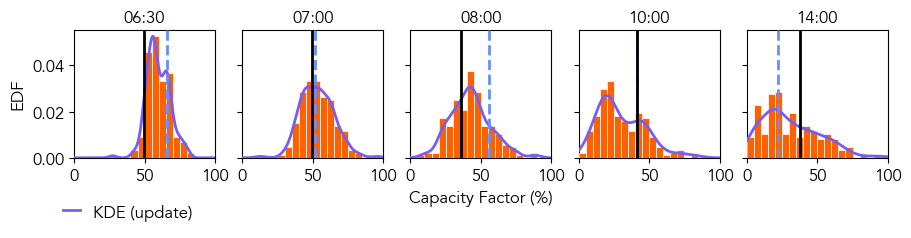

In [52]:
def _plot_histogram_cuts(_ax, 
                         KDs_, 
                         M_, 
                         f_, 
                         f_hat_, 
                         e_, 
                         dx_, 
                         dt_, 
                         slices_, 
                         interval):

    tau_ = dt_[:interval]
    s_ = dt_[interval:]

    x_ = np.linspace(0, 100, 1000)[:, np.newaxis]

    for slice, i in zip(slices_, range(len(slices_))):
        z_ = np.exp(KDs_[slice].score_samples(x_))

        _ax[i].axvline(100 * f_hat_[slice],
                       color=palette_.loc[0, "ibm"],
                       lw=2,
                       ls="--",
                       #label="CF (actual)",
                       zorder=10)

        _ax[i].axvline(100 * e_[interval + slice], 
                       color="k", 
                       lw=2, 
                       #label="CF (forecast)", 
                       zorder=10)

        _ax[i].hist(100 * M_[:, slice],
                    bins=20,
                    range=(0, 100),
                    density=True,
                    color=palette_.loc[3, "ibm"], clip_on = True,
                    zorder=8, 
                    edgecolor='w', 
                    linewidth=.5)

        _ax[i].plot(x_, z_,
                    label="KDE (update)",
                    color=palette_.loc[1, "ibm"],
                    lw=2,
                    zorder=9)

        _ax[i].set_title(dx_[interval:][slice], size=12)
        _ax[i].set_xlim(0, 100)
        _ax[i].set_ylim(0,)
        
        
        _ax[i].tick_params(axis="both",
                           labelsize=12)

    _ax[0].set_ylabel("EDF", size=12)
    _ax[2].set_xlabel("Capacity Factor (%)", size=12)

    _ax[0].legend(frameon=False, 
                   fontsize=12, loc = (-.125, -0.55))

slices_ = [6, 12, 24, 48, 96]

KDs_ = _fdu.kernel_density_estimation(100 * M_, algorithm = "auto", kernel = "gaussian")

_fig, _ax = plt.subplots(1, len(slices_), 
                         figsize=(9, 2.25), 
                         sharey=True, 
                         layout="constrained")

_plot_histogram_cuts(_ax, 
                     KDs_, 
                     M_, 
                     f_, 
                     f_hat_, 
                     e_bias_, 
                     dx_, 
                     dt_, 
                     slices_,
                     interval)

plt.savefig(path_to_images + f"/marginal_density_cutoffs-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

In [53]:
F_curves_ = []
M_curves_ = []
D_curves_ = []
for interval in range(12, 276, 3):

    _fdu.predict(F_ts_[day, :interval, asset], E_ts_lin_[day, :, asset],
                 forget_rate_f = _get_hyper(hyper_, 'forget_rate_f', interval),
                 forget_rate_e = _get_hyper(hyper_, 'forget_rate_e', interval),
                 length_scale_f = _get_hyper(hyper_, 'length_scale_f', interval),
                 length_scale_e = _get_hyper(hyper_, 'length_scale_e', interval),
                 lookup_rate = _get_hyper(hyper_, 'lookup_rate', interval),
                 trust_rate = _get_hyper(hyper_, 'trust_rate', interval),
                 nu = _get_hyper(hyper_, 'nu', interval),
                 gamma = _get_hyper(hyper_, 'gamma', interval),
                 xi = _get_hyper(hyper_, 'xi', interval),
                 kappa = _get_hyper(hyper_, 'kappa', interval),
                 p_fusion = _get_hyper(hyper_, 'p_fusion', interval))

    # Compute depth to find the focal curve
    _F = FDataGrid(data_matrix = _fdu.M_,
                   grid_points = _fdu.dt_[interval:])

    depth_rank_ = np.argsort(_depth(_F))[::-1]
    
    M_curves_.append(np.median(_fdu.M_, axis = 0))
    F_curves_.append(_fdu.f_focal_)
    D_curves_.append(_fdu.M_[depth_rank_[0], :])

print(len(F_curves_), len(M_curves_), len(D_curves_))

88 88 88


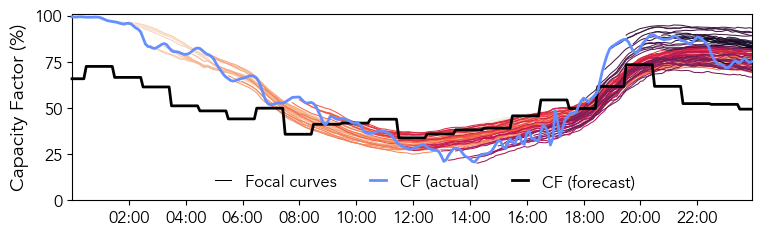

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


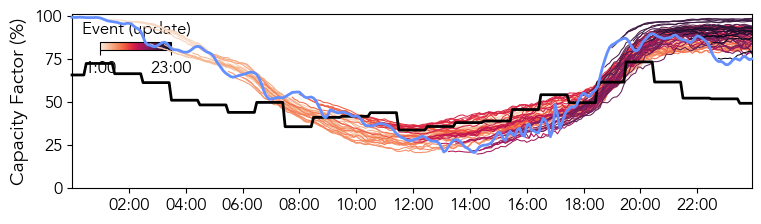

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


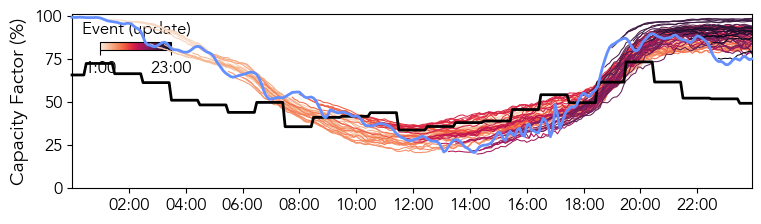

In [54]:
def _plot_dynamic_update(_ax, 
                         F_curves_, 
                         f_, 
                         f_hat_, 
                         e_, 
                         dx_, 
                         dt_,
                         legend = False,
                         colorbar = True,
                         label = r"$\bar{f} (s)$"):

    f_p_ = np.concatenate([f_, f_hat_], axis = 0)

    _cmap = sns.color_palette("rocket_r", as_cmap=True)
    _norm = plt.Normalize(0., len(F_curves_))

    _ax.plot([], [], 
             lw = 0.75,
             label = label if legend else None, 
             c = "k")
    
    _ax.plot(dt_, 100 * f_p_, 
             c = palette_.loc[0, "ibm"], 
             zorder = 10, 
             label = "CF (actual)" if legend else None, 
             lw = 2, 
             clip_on = False)

    _ax.plot(dt_, 100 * e_, 
             lw = 2, 
             zorder = 9, 
             label = "CF (forecast)" if legend else None, 
             c = "k", 
             clip_on = False)
    
    for i in range(len(F_curves_)):
        focal_curve_ = F_curves_[i]

        _ax.plot(dt_[-focal_curve_.shape[0]:], 100 * focal_curve_, 
                 c = _cmap(_norm(i)), 
                 lw = .75, 
                 zorder = 8)
    
    _ax.set_xticks(dt_[24::24], dx_[24::24], rotation=0)
    _ax.set_ylim(0.0, 101)
    _ax.set_xlim(dt_[0], dt_[-1])
    _ax.set_ylabel("Capacity Factor (%)", size=14)

    _ax.tick_params(axis="both", 
                    labelsize=12)

    if colorbar: 
        cbar = _fig.colorbar(cm.ScalarMappable(_norm, _cmap),
                             cax=_ax.inset_axes([60, 80, 150, 5], transform=_ax.transData),
                             orientation="horizontal")
    
        cbar.set_ticks([0, len(F_curves_)], 
                       labels=["1:00", "23:00"], 
                       size=12)
        
        #cbar.ax.tick_params(length=0)
        
        cbar.ax.set_title("Event (update)", 
                          rotation=0, 
                          size=12)

_fig, _ax = plt.subplots(figsize = (7.5, 2.25), constrained_layout = True)

_plot_dynamic_update(_ax, F_curves_, f_, f_hat_, e_bias_, dx_, dt_,
                     label = 'Focal curves',
                     legend = True,
                     colorbar = False)

_ax.legend(loc=(0.2, 0.0125),
           frameon=False, 
           fontsize=12, 
           ncol=3)

plt.savefig(path_to_images + f"/dynamic_update-focal_curve-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

_fig, _ax = plt.subplots(figsize = (7.5, 2.125), constrained_layout = True)

_plot_dynamic_update(_ax, M_curves_, f_, f_hat_, e_bias_, dx_, dt_, 
                    label = 'Marginal medians')

_ax.legend(loc=(0.25, 0.),
           frameon=False, 
           fontsize=12, 
           ncol=3)

plt.savefig(path_to_images + f"/dynamic_update-median_marginals-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

_fig, _ax = plt.subplots(figsize = (7.5, 2.125), constrained_layout = True)

_plot_dynamic_update(_ax, 
                     M_curves_, 
                     f_, 
                     f_hat_, 
                     e_bias_, 
                     dx_, 
                     dt_, 
                     label = 'Deepest curves')

_ax.legend(loc=(0.25, 0.),
           frameon=False, 
           fontsize=12, 
           ncol=3)

plt.savefig(path_to_images + f"/dynamic_update-deepest_curve-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

(67881,) (183,) (2662, 2) (183, 2)


 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:844: ShapelyDeprecationWarning:__len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:855: ShapelyDeprecationWarning:Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:850: ShapelyDeprecationWarning:__getitem__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
 <__array_function__ internals>:5: ShapelyDeprecationWarning:The array interface is deprecated and will

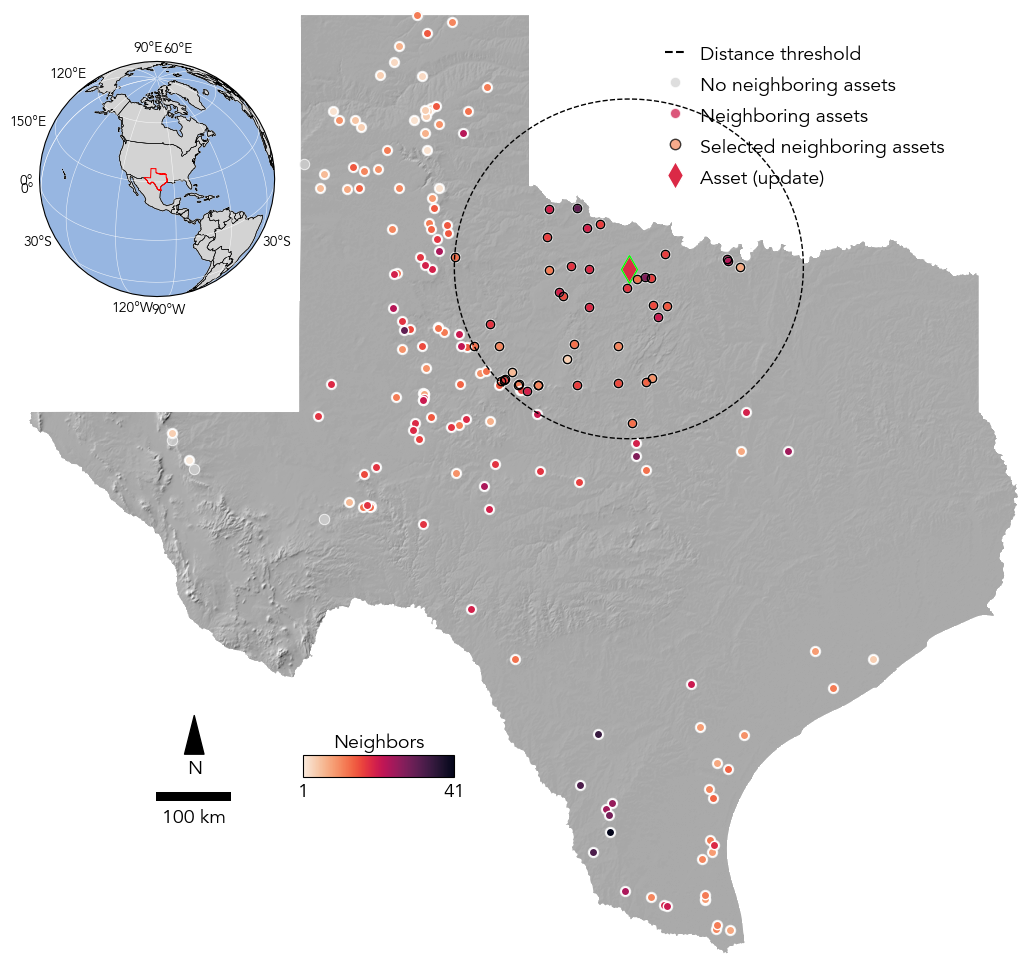

In [55]:
import ee, geemap

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from cartopy.mpl.geoaxes import GeoAxes
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

def _hillshade(_ax, 
               _shapefile):

    # Initialize Earth Engine
    ee.Initialize()
    
    # Get the bounding box from 
    bounds = _shapefile.total_bounds  # [minx, miny, maxx, maxy]
    roi = geemap.geopandas_to_ee(_shapefile)  # Convert GeoDataFrame to EE FeatureCollection
    
    _DEM = ee.Image('USGS/SRTMGL1_003').select('elevation')
    #hillshade = ee.Terrain.hillshade(_DEM, 180, 22.5)
    hillshade = ee.Terrain.hillshade(_DEM, 315, 21)
    #hillshade = ee.Terrain.hillshade(_DEM, 315, 20).unitScale(0, 255).pow(1.4).multiply(255) 

    # Download hillshade as a NumPy array
    hillshade_np = geemap.ee_to_numpy(hillshade.clip(roi), 
                                      region=roi, 
                                      scale=1000).astype(float)

    hs = hillshade_np.squeeze()
    hs[hs == 0] = np.nan

    # Create a colormap and set NaNs (bad values) to transparent
    _cmap = cm.get_cmap("Greys_r").copy()
    #_cmap = cm.get_cmap("gray").copy()
    _cmap.set_bad(color=(0, 0, 0, 0))  # RGBA: transparent

    _ax.imshow(hs, 
               cmap=_cmap, 
               extent=[bounds[0], bounds[2], bounds[1], bounds[3]], 
               origin='upper', 
               vmin=1)
    
    return _ax


def _plot_frequency_map(_fig, 
                        _ax, 
                        _fdu, 
                        shape_, 
                        x_tr_, 
                        x_ts_, 
                        x_, 
                        idx_neighbors_, 
                        idx_temporal_, 
                        idx_spatial_, 
                        sigma):

    y_tr_ = x_tr_[idx_neighbors_, :]
    x_tr_p_, inv_idx_, z_tr_p_ = np.unique(y_tr_, 
                                           return_inverse=True,
                                           return_counts = True, 
                                           axis = 0)

    z_tr_pp_ = z_tr_p_[inv_idx_]
    
    # Step 3: expand back to full x_tr_
    z_tr_ = np.zeros(x_tr_.shape[0], dtype=int)
    z_tr_[idx_neighbors_] = z_tr_pp_

    print(z_tr_.shape, z_tr_p_.shape, y_tr_.shape, x_tr_p_.shape)
    
    _cmap = sns.color_palette("rocket_r", as_cmap=True)
    _norm = plt.Normalize(1, z_tr_p_.max())

    shape_.plot(ax = _ax, 
                facecolor = 'None', 
                edgecolor = 'w')
    
    # _ax.scatter(x_[0], x_[1],
    #             c="lime",
    #             lw=1,
    #             ec="k",
    #             s=110,
    #             zorder=1,
    #             marker="o",
    #             clip_on=False,
    #             label="Asset (update)")
    
    _ax.plot(x_[0], x_[1],
             c="k",
             marker="None",
             ls="--",
             clip_on=False,
             label="Distance threshold")

    _ax.plot(x_ts_[:, 0], x_ts_[:, 1],
             c="lightgray",
             alpha=0.75,
             ms=7.5,
             marker="o",
             mec="w",
             ls="none",
             mew=.75,
             zorder=2, 
             clip_on=False,
             label="No neighboring assets")
    
    _ax.plot(x_[0], x_[1],
             c=_cmap(_norm(z_tr_p_.max()/2.)),
             alpha=0.75,
             ms=7.5,
             ls="none",
             marker="o",
             mec="w",
             mew=1.0,
             zorder=0, 
             clip_on=False,
             label="Neighboring assets")

    _ax.plot(x_[0], x_[1],
             c=_cmap(_norm(z_tr_p_.max()/4.)),
             alpha=0.75,
             ms=7.5,
             ls="none",
             marker="o",
             mec="k",
             mew=1.0,
             zorder=0, 
             clip_on=False,
             label="Selected neighboring assets")

    for i in np.arange(x_tr_p_.shape[0], dtype=int)[np.argsort(z_tr_p_)]:
        if (x_tr_p_[i, 0] != x_[0]) | (x_tr_p_[i, 1] != x_[1]):
            _ax.plot(x_tr_p_[i, 0], x_tr_p_[i, 1],
                     c=_cmap(_norm(z_tr_p_[i])),
                     ms=6,
                     ls="none",
                     marker="o",
                     mec="w",
                     mew=1.,
                     zorder=6, 
                     clip_on=False)
        else:
            _ax.plot(x_tr_p_[i, 0], x_tr_p_[i, 1],
                     c=_cmap(_norm(z_tr_p_[i])),
                     ms=14,
                     ls="none",
                     marker="d",
                     mec="w",
                     mew=1.,
                     zorder=4, 
                     label = 'Asset (update)',
                     clip_on=False)

    x_tr_p_ = np.unique(x_tr_[idx_spatial_, :], axis=0)
    for i in range(x_tr_p_.shape[0]):
        if (x_tr_p_[i, 0] != x_[0]) | (x_tr_p_[i, 1] != x_[1]):
            _ax.plot(x_tr_p_[i, 0], x_tr_p_[i, 1],
                     ms=6,
                     ls="none",
                     marker="o",
                     c = 'none', 
                     mec="k",
                     mew=1.,
                     zorder=7, 
                     clip_on=False)
        else:
            _ax.plot(x_tr_p_[i, 0], x_tr_p_[i, 1],
                     ms=14,
                     ls="none",
                     marker="d",
                     c = 'none', 
                     mec="lime",
                     mew=1.,
                     zorder=5, 
                     #label = 'Asset (update)',
                     clip_on=False)
    
    minx, miny, maxx, maxy = shape_.total_bounds
    X_, Y_ = np.meshgrid(np.linspace(minx, maxx, 1000), 
                         np.linspace(miny, maxy, 1000))
    
    Z_ = _fdu._haversine_dist(
        x_, np.concatenate([X_.flatten()[:, np.newaxis], 
                            Y_.flatten()[:, np.newaxis]], axis = 1)
    ).reshape(X_.shape)

    contours = _ax.contour(X_, Y_, Z_, 
                           levels = [sigma], 
                           colors = 'k', 
                           linewidths = 1., 
                           linestyles = 'dashed', 
                           zorder = 11)

    cbar = _fig.colorbar(cm.ScalarMappable(cmap = _cmap),
                         cax=_ax.inset_axes([-103, 27.85, 2.0, 0.25], transform = _ax.transData),
                         orientation="horizontal")

    cbar.set_ticks([0, 1], 
                   labels=[1, int(z_tr_p_.max())], 
                   fontsize=14)
    
    cbar.ax.tick_params(length=0)
    
    cbar.ax.set_title("Neighbors", 
                      rotation = 0, 
                      fontsize = 14)

    _ax.set_axis_off()
    

def _globe_inset(_ax, 
                 _TX, 
                 x0, 
                 y0, 
                 width = 0.25, 
                 height = 0.25):
    """
    Add an orthographic globe inset centered on Texas.

    Parameters
    ----------
    _ax : matplotlib Axes / GeoAxes
        Parent axes where the inset will be placed.
    _TX : GeoDataFrame
        Texas geometry.
    x0, y0 : float
        Lower-left corner of the inset in parent axes coordinates (0–1).
    width, height: float
        Size of the inset, also in parent axes coordinates (0–1).
    """

    # --- Data prep ---
    _world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
    _world = _world.to_crs(epsg=4326)
    _TX = _TX.to_crs(epsg=4326)

    shape_centroid = _TX.geometry.unary_union.centroid

    ortho = ccrs.Orthographic(central_longitude=shape_centroid.x,
                              central_latitude=shape_centroid.y)

    # Use inset_axes *function*, not _ax.inset_axes
    # bbox_to_anchor=(x0, y0, width, height) is in _ax.transAxes
    _ax_inset = inset_axes(_ax,
                           width="100%",   # 100% of the bbox width
                           height="100%",  # 100% of the bbox height
                           bbox_to_anchor=(x0, y0, width, height),
                           bbox_transform=_ax.transAxes,
                           axes_class=GeoAxes,
                           axes_kwargs=dict(map_projection=ortho),
                           borderpad=0.0)

    # --- Drawing ---
    _ax_inset.add_geometries(_world.geometry,
                             crs=ccrs.PlateCarree(),
                             facecolor="none",
                             edgecolor="k",
                             linewidth=0.25)

    _ax_inset.add_geometries(_TX.geometry,
                             crs=ccrs.PlateCarree(),
                             facecolor="none",
                             edgecolor="r",
                             zorder=10,
                             linewidth=.75)

    gl = _ax_inset.gridlines(crs=ccrs.PlateCarree(),
                             draw_labels=True,      # no labels – small inset
                             linewidth=0.4,
                             color="white",
                             alpha=.825,
                             xlocs=range(-180, 181, 30),
                             ylocs=range(-90, 91, 30))
    
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    _ax_inset.coastlines(linewidth=0.5)
    _ax_inset.add_feature(cfeature.OCEAN, zorder=0)
    _ax_inset.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
    _ax_inset.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=2)
    _ax_inset.set_global()

_fig, _ax = plt.subplots(1, 1, 
                        figsize=(10, 10), 
                        layout="constrained")

# Add an inset globe showing Texas
_globe_inset(_ax, _TX, 
             x0=0.005, 
             y0=0.7, 
             width=0.25, 
             height=0.25)

_ax = _hillshade(_ax, _TX)

_plot_frequency_map(_fig, 
                    _ax, 
                    _fdu, 
                    _TX, 
                    X_tr_, 
                    x_ts_, 
                    _fdu.x_,
                    _fdu.idx_neighbors_,
                    _fdu.idx_temporal_, 
                    _fdu.idx_spatial_, 
                    _fdu.sigma)

# Add compass (North arrow)
x, y, arrow_length = 0.1675, 0.2575, 0.06  # relative axes coords

_ax.annotate("N",
             xy=(x, y),
             xytext=(x, y - arrow_length),
             arrowprops=dict(facecolor="k", 
                             arrowstyle="wedge,tail_width=1,shrink_factor=.5"),
             ha="center",
             va="center",
             fontsize=14,
             xycoords=_ax.transAxes)

scalebar = ScaleBar(dx=100,  # scaling factor
                    units="km",
                    dimension="si-length",  # could also be 'imperial-length.'
                    location='lower left',
                    length_fraction=0.09,  # fraction of the axis for bar length
                    color="black",
                    box_color="None",
                    box_alpha=1.0,
                    border_pad=9,
                    font_properties={"size": 14})

_ax.add_artist(scalebar)

_ax.legend(frameon=False,
           bbox_to_anchor=(0.625, 0.9875),
           ncol=1,
           fontsize=14)

plt.savefig(path_to_images + f"/hillshade_neighboring_assets-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

-0.11719467401285566 0.13965411692684415
[ 0.13965412 -0.08115243 -0.05031374 -0.05880777  0.09500306  0.10449189
  0.02720386 -0.0404423  -0.11719467 -0.018442  ]


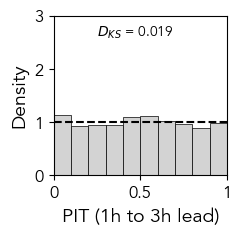

-0.11015457606366674 0.3146235078053259
[ 0.31462351 -0.03917968 -0.0479798  -0.11015458 -0.09217172 -0.04315886
 -0.04090144  0.03676921 -0.04893633  0.07108968]


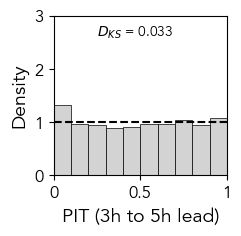

In [35]:
def clean_fmt(x, pos):
    if abs(x - round(x)) < 1e-9:
        return str(int(round(x)))
    return f"{x:.2g}"

def _plot_PIT(_ax, u_, 
              bins=10,
              v=0.5,
              xlabel = 'PIT'):
    
    vmin= -v
    vmax= v
    
    KS_stat = _KS(u_)
    u_ = np.sort(u_)
    n = len(u_)

    # --- Histogram ---
    counts_, bins_, patches = _ax.hist(u_,
                                       bins=bins,
                                       range=(0.0, 1.0),
                                       density=True,
                                       lw=0.5,
                                       edgecolor='k',
                                       alpha=1)

    # deviation from perfect calibration
    deviation = counts_ - 1.
    #print(deviation.min(), deviation.max())
    #print(deviation)
    
    # --- Colormap centered at 0 ---
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    cmap = cm.get_cmap("coolwarm")

    for patch, dev in zip(patches, deviation):
        #patch.set_facecolor(cmap(norm(dev)))
        patch.set_facecolor('lightgray')

    # --- Reference line ---
    _ax.axhline(1.0, 
                c = 'k',
                linestyle='--')

    _ax.set_xlim(0, 1)
    _ax.set_ylim(0, 3)

    #_ax.set_xlabel("u = F̂(y_obs)")
    _ax.set_xlabel(xlabel, size=14)
    _ax.set_ylabel("Density", size=14)

    _ax.xaxis.set_major_formatter(FuncFormatter(clean_fmt))

    _ax.tick_params(axis="both", labelsize=12)

    # --- Annotate KS statistic ---
    _ax.text(0.25, 0.95,
             f"$D_{{KS}}$ = {KS_stat:.3f}",
             transform=_ax.transAxes,
             verticalalignment='top')


time = 72

U_ = pd.read_csv(path_to_validation + f"/{resource}_fusion_{time}_ts.csv", 
                 low_memory=False).to_numpy()

_fig, _ax = plt.subplots(1, 1, 
                        figsize = (2.3, 2.25), 
                        layout  = "constrained")

lead = 0
bins = 10
_plot_PIT(_ax, U_[:, lead*12:(lead + 3)*12].flatten(), bins,
          xlabel = 'PIT (1h to 3h lead)')

plt.savefig(path_to_images + f"/PIT-{resource}-{lead}-{bins}-{time}.pdf", 
            bbox_inches = "tight")

plt.show()

_fig, _ax = plt.subplots(1, 1, 
                        figsize = (2.3, 2.25), 
                        layout  = "constrained")

lead = 3

_plot_PIT(_ax, U_[:, lead*12:(lead + 3)*12].flatten(), bins, 
          v = 0.4,
          xlabel = 'PIT (3h to 5h lead)')

plt.savefig(path_to_images + f"/PIT-{resource}-{lead}-{bins}-{time}.pdf", 
            bbox_inches = "tight")

plt.show()